In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


from matplotlib.colors import LinearSegmentedColormap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## EDA

In [2]:
data = pd.read_csv("uber_fares.csv")
data.head()

,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:50:00,8.47,2015-05-07 19:50:00 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:00:04,7.60,2009-07-17 20:00:04 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:49:07,12.65,2009-08-24 21:49:07 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:17:45,5.01,2009-06-26 08:17:45 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:46:18,15.64,2014-08-28 17:46:18 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [3]:
print(data.shape) # (fila, columna)          
print(data.dtypes) # Tipo de dato por columna

(200000, 9)
key                    int64
date                     str
fare_amount          float64
pickup_datetime          str
pickup_longitude     float64
pickup_latitude      float64
dropoff_longitude    float64
dropoff_latitude     float64
passenger_count        int64
dtype: object


Con esto podemos ver que hay 200.000 registros, cada uno con 9 columnas (['key', 'date', 'fare_amount', 'pickup_datetime', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count']).

Además, vemos que 'date' y 'pickup_datetime' son str, esto lo modificaremos más adelante para un correcto uso de la información que poseen estas columnas.  

In [4]:
# Para iniciar la limpieza revisamos si hay datos duplicados. 

duplicados_totales = data.duplicated().sum()
duplicados_key = data["key"].duplicated().sum()

print("Duplicados totales:", duplicados_totales)
print("Duplicados en key:", duplicados_key)

vacios = data.isna().sum()

print(f"\n {vacios}")


Duplicados totales: 0
Duplicados en key: 0

 key                  0
date                 0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64


Revisamos los duplicados tanto de los registros completos como de las key. Este último debido a que al ser el identificador de cada viaje, demostraría una inconsistencia en el dataset en caso de que los hubiera. 

También podemos ver que hay un viaje que no tiene dropoff_longitude ni dropoff_latitude, como si nunca hubiese terminado. Decidimos eliminarlo, ya que lo consideramos un dato que puede generar ruido en el modelo y no es significativo a la cantidad de registros. 

In [5]:
data = data.dropna()

In [6]:
pickup_sin_tz = data["pickup_datetime"].str.split(" ", n=2).str[:2].str.join(" ")
igualdad = (data["date"] == pickup_sin_tz).all()
print(f"¿Poseen los mismos datos en todos los registros? (True/False): {igualdad}")

data["pickup_datetime"] = pd.to_datetime(data["pickup_datetime"], errors="coerce")
data["date"] = pd.to_datetime(data["date"], errors="coerce")


¿Poseen los mismos datos en todos los registros? (True/False): True


Al comprobar que 'date' y 'pickup_datetime' poseen el mismo dato, con la diferencia de que la segunda tiene también la zona horaria, podemos proceder a eliminar date, para no tener información innecesariamente duplicada. 

In [7]:
data = data.drop(columns=["date"])

data["year"] = data["pickup_datetime"].dt.year
data["month"] = data["pickup_datetime"].dt.month
data["day"] = data["pickup_datetime"].dt.day
data["hour"] = data["pickup_datetime"].dt.hour
data["weekday"] = data["pickup_datetime"].dt.weekday
data["timezone"] = data["pickup_datetime"].dt.tz

data = data.drop(columns=["pickup_datetime"])

Separamos los datos de 'pickup_datetime' en año, mes, día, hora, día de la semana y zona horaria para conservar la información de forma que sea utilizable luego. Luego de hacer esto decidimos eliminar la columna 'pickup_datetime' para no tener redundancias innecesarias. 

In [8]:
# Visualizamos como queda el df.
data.head()

,key,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,weekday,timezone
0,24238194,8.47,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,7,19,3,UTC
1,27835199,7.60,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,17,20,4,UTC
2,44984355,12.65,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,24,21,0,UTC
3,25894730,5.01,-73.976124,40.790844,-73.965316,40.803349,3,2009,6,26,8,4,UTC
4,17610152,15.64,-73.925023,40.744085,-73.973082,40.761247,5,2014,8,28,17,3,UTC


In [9]:
data.describe(percentiles=[.01, .05, .25, .50, .75, .95, .99])

,key,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,weekday
count,1.999990e+05,199999.000000,199999.000000,199999.000000,199999.000000,199999.000000,199999.000000,199999.000000,199999.000000,199999.000000,199999.000000,199999.000000
mean,2.771248e+07,11.362851,-72.527631,39.935881,-72.525292,39.923890,1.684543,2011.742429,6.281841,15.704814,13.492617,3.048305
std,1.601386e+07,9.943232,11.437815,7.720558,13.117408,6.794829,1.385995,1.856395,3.438952,8.687419,6.513288,1.946946
min,1.000000e+00,1.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000,2009.000000,1.000000,1.000000,0.000000,0.000000
1%,5.539071e+05,2.950000,-74.014402,0.000000,-74.015288,0.000000,1.000000,2009.000000,1.000000,1.000000,0.000000,0.000000
5%,2.723432e+06,3.940000,-74.006838,40.701801,-74.007460,40.686410,1.000000,2009.000000,1.000000,2.000000,1.000000,0.000000
25%,1.382534e+07,5.970000,-73.992065,40.734796,-73.991407,40.733823,1.000000,2010.000000,3.000000,8.000000,9.000000,1.000000
50%,2.774524e+07,8.430000,-73.981823,40.752592,-73.980093,40.753042,1.000000,2012.000000,6.000000,16.000000,14.000000,3.000000
75%,4.155535e+07,12.660000,-73.967154,40.767158,-73.963658,40.768001,2.000000,2013.000000,9.000000,23.000000,19.000000,5.000000
95%,5.265729e+07,30.300000,-73.871199,40.787702,-73.874212,40.793744,5.000000,2015.000000,12.000000,29.000000,22.000000,6.000000


Viendo la salida del .describe() apreciamos valores extremos tanto de latitudes y longitudes, decidimos entonces eliminar todos los registros que tengan coordenadas no existentes, sea:

- latitud fuera de [-90, 90]
- longitud fuera de [-180, 180]
- valores 0, 0 o una de las coordenadas en 0

In [10]:
filtro_coords_validas = (
    data["pickup_latitude"].between(-90, 90) &
    data["dropoff_latitude"].between(-90, 90) &
    data["pickup_longitude"].between(-180, 180) &
    data["dropoff_longitude"].between(-180, 180)
)

data = data[filtro_coords_validas]

filtro_no_ceros = (
    (data["pickup_latitude"] != 0) &
    (data["pickup_longitude"] != 0) &
    (data["dropoff_latitude"] != 0) &
    (data["dropoff_longitude"] != 0)
)

data = data[filtro_no_ceros]

Vemos también que 'passenger_count' se puede ver que hay un viaje con más de doscientos pasajeros y algunos con cero, se asume que son errores de input, ya que la cantidad de pasajeros los ingresa el chofer, pero haremos un mejor estudio de los mismos y se determinará que hacer con ellos.

In [11]:
print(data["passenger_count"].value_counts().sort_index())

passenger_count
0         686
1      135635
2       28865
3        8708
4        4182
5       13740
6        4202
208         1
Name: count, dtype: int64


Que haya seis pasajeros, aunque sería incómodo a menos que se trate de un vehículo tipo SUV puede ser plausible, mientras que viajes con 0 o 208 son considerados un error en el dataset, y tambien eliminados para no comprometer la calidad del modelo.

Se consideró la posibilidad de que los viajes indicados con cero pasajeros sean envíos de paquetería, pero no hay documentación que lo respalde. 

In [12]:
data = data[(data["passenger_count"] > 0) & (data["passenger_count"] <= 6)].copy()
print(data["passenger_count"].value_counts().sort_index())

passenger_count
1    135635
2     28865
3      8708
4      4182
5     13740
6      4202
Name: count, dtype: int64


Para comprender un poco mejor la distribución geográfica del dataset, se hará un mapa interactivo de los puntos de inicio y finalización de viajes. 

In [13]:
muestra = data.sample(20000, random_state=33).copy()

pickups = muestra[["pickup_latitude", "pickup_longitude"]].copy()
pickups.columns = ["lat", "lon"]
pickups["tipo"] = "Origen"

dropoffs = muestra[["dropoff_latitude", "dropoff_longitude"]].copy()
dropoffs.columns = ["lat", "lon"]
dropoffs["tipo"] = "Destino"

mapa_df = pd.concat([pickups, dropoffs], ignore_index=True)

fig = px.scatter_map(
    mapa_df,
    lat="lat",
    lon="lon",
    color="tipo",
    zoom=10,
    height=700,
    title="Puntos de inicio y finalización de los viajes",
    labels={"tipo": "Tipo de punto"},
    color_discrete_map={
        "Origen": "#00daff",
        "Destino": "#073D47"
        }
)

fig.update_layout(    
    map_style="open-street-map",
    title_x=0.5)
fig.show()

Observamos en el mapa dos situaciones que nos parece importante tener en consideración:

- Por un lado, la mayor concentración de viajes se encuentra dentro de Estados Unidos, principalmente al rededor de Nueva York. 
- Por otro, aun habiendo eliminado las coordenadas inexistentes, aparecen registros fuera del área geográfica de interés o ubicados sobre el océano, por lo que decidimos restringir el análisis a los viajes dentro de Estados Unidos.

In [14]:
exterior = data[
    ~(
        ((data["pickup_latitude"].between(24, 50))        &
         (data["pickup_longitude"].between(-125, -65)))   &
        ((data["dropoff_latitude"].between(24, 50))       &
         (data["dropoff_longitude"].between(-125, -65)))  
    )]
    
data = data.drop(exterior.index)

data.head()

,key,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,weekday,timezone
0,24238194,8.47,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,7,19,3,UTC
1,27835199,7.60,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,17,20,4,UTC
2,44984355,12.65,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,24,21,0,UTC
3,25894730,5.01,-73.976124,40.790844,-73.965316,40.803349,3,2009,6,26,8,4,UTC
4,17610152,15.64,-73.925023,40.744085,-73.973082,40.761247,5,2014,8,28,17,3,UTC


Consideramos que un dato importante que tener es la distancia recorrida en cada viaje, calculamos una estimación de esta distancia con la ecuación de Haversine.

In [15]:
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    a = np.clip(a, 0, 1)

    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

data["distance_km"] = haversine_distance(
    data["pickup_latitude"],
    data["pickup_longitude"],
    data["dropoff_latitude"],
    data["dropoff_longitude"]
)

data.head()

,key,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,weekday,timezone,distance_km
0,24238194,8.47,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,7,19,3,UTC,1.683323
1,27835199,7.60,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,17,20,4,UTC,2.457590
2,44984355,12.65,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,24,21,0,UTC,5.036377
3,25894730,5.01,-73.976124,40.790844,-73.965316,40.803349,3,2009,6,26,8,4,UTC,1.661683
4,17610152,15.64,-73.925023,40.744085,-73.973082,40.761247,5,2014,8,28,17,3,UTC,4.475450


Realizamos a continuación los Histogramas y Boxplot de las variables 'Tarifas' y 'Distancia' para ver sus distribuciones.

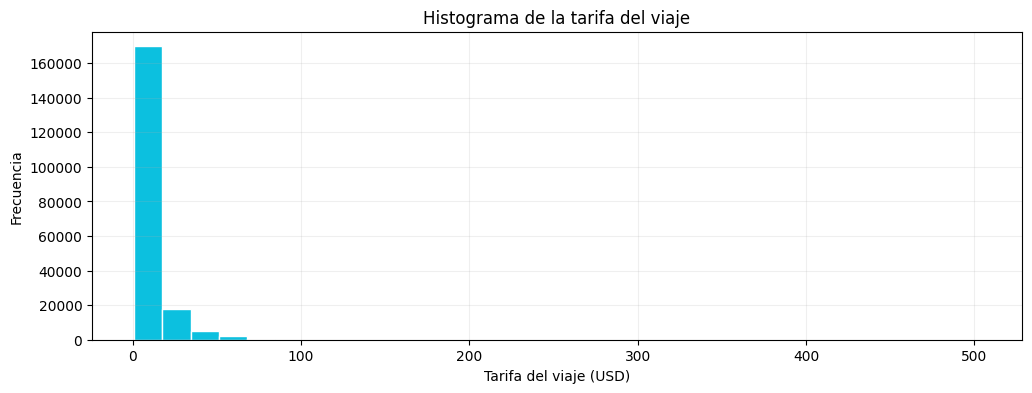

In [16]:
plt.figure(figsize=(12, 4))
data["fare_amount"].hist(bins=30, color="#0cc0df", edgecolor="#FFFFFF")
plt.grid(True, alpha=0.2)
plt.title("Histograma de la tarifa del viaje")
plt.xlabel("Tarifa del viaje (USD)")
plt.ylabel("Frecuencia")
plt.show()

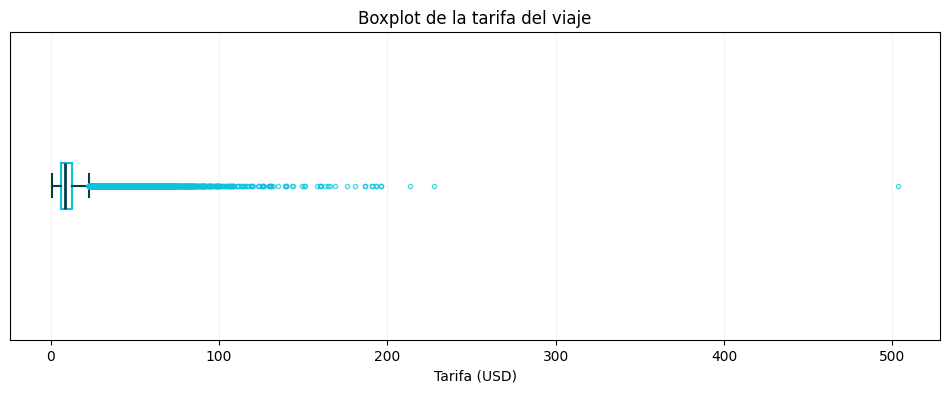

In [17]:
plt.figure(figsize=(12, 4))

plt.boxplot(
    data["fare_amount"],
    orientation="horizontal",
    patch_artist=True,
    boxprops=dict(facecolor="none", edgecolor="#0cc0df", linewidth=1.5),
    medianprops=dict(color="#073D47", linewidth=2),
    whiskerprops=dict(color="#073D47", linewidth=1.5),
    capprops=dict(color="#073D47", linewidth=1.5),
    flierprops=dict(
        marker="o",
        markerfacecolor="none",
        markeredgecolor="#0cc0df",
        markeredgewidth=1,
        markersize=3,
        alpha=0.7
    )
)

plt.title("Boxplot de la tarifa del viaje")
plt.xlabel("Tarifa (USD)")
plt.yticks([])
plt.grid(True, axis="x", alpha=0.15)
plt.show()

In [18]:
data["fare_amount"].describe(percentiles=[.01, .05, .25, .50, .75, .95, .99])

count    195173.000000
mean         11.351422
std           9.854040
min           1.000000
1%            2.980000
5%            3.950000
25%           5.980000
50%           8.430000
75%          12.660000
95%          30.230000
99%          53.880000
max         503.130000
Name: fare_amount, dtype: float64

Acá podemos ver bastante bien que la mayoría de las tarifas se mueve en un rango bajo: la mediana es de 8.43 USD y el 75% de los viajes no pasa de 12.66 USD. Aun así, hay una cola superior bastante marcada, porque mientras el percentil 99 llega a 53.88 USD, el máximo se dispara hasta 503.13 USD. Esto sugiere que hay valores extremos que se alejan bastante del comportamiento general de la variable y que podrían ser atípicos. 

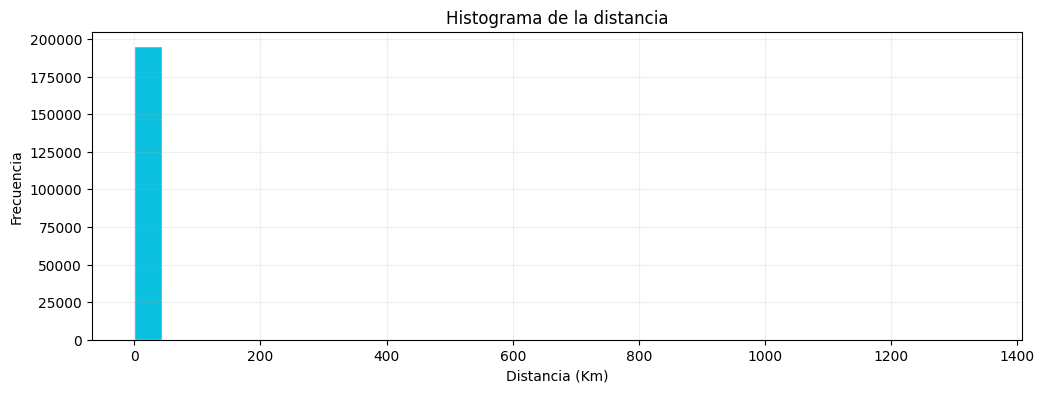

In [19]:
plt.figure(figsize=(12, 4))
data["distance_km"].hist(bins=30, color="#0cc0df", edgecolor="#FFFFFF")
plt.grid(True, alpha=0.2)
plt.title("Histograma de la distancia")
plt.xlabel("Distancia (Km)")
plt.ylabel("Frecuencia")
plt.show()

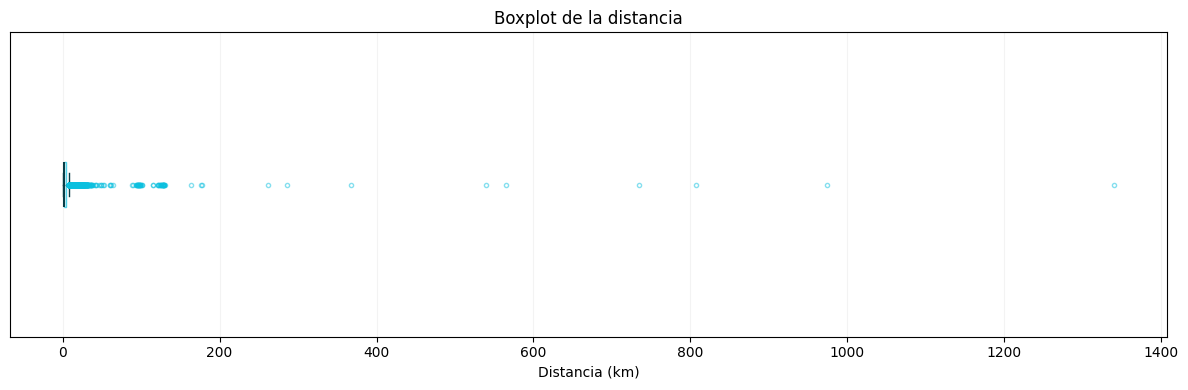

In [20]:
plt.figure(figsize=(12, 4))

plt.boxplot(
    data["distance_km"],
    orientation="horizontal",
    patch_artist=True,
    boxprops=dict(facecolor="none", edgecolor="#0cc0df", alpha=0.7),
    medianprops=dict(color="#073D47", linewidth=1.5),
    whiskerprops=dict(color="#073D47"),
    capprops=dict(color="#073D47"),
    flierprops=dict(
        marker="o",
        markerfacecolor="none",
        markeredgecolor="#0cc0df",
        markersize=3,
        alpha=0.5
    )
)

plt.title("Boxplot de la distancia")
plt.xlabel("Distancia (km)")
plt.yticks([])
plt.grid(True, axis="x", alpha=0.15)
plt.tight_layout()
plt.show()

In [21]:
data["distance_km"].describe(percentiles=[.01, .05, .25, .50, .75, .95, .99])

count    195173.000000
mean          3.376782
std           6.391574
min           0.000000
1%            0.000000
5%            0.561803
25%           1.255903
50%           2.157198
75%           3.909870
95%          10.022799
99%          20.401307
max        1340.106401
Name: distance_km, dtype: float64

En distance_km pasa algo parecido, pero todavía más marcado. La mediana es de 2.16 km y el 75% no supera los 3.91 km, así que la mayoría son trayectos cortos. Sin embargo, aparecen algunos valores muy alejados del resto: el percentil 99 está en 20.40 km, pero el máximo llega a 1340.11 km. Eso muestra una distribución muy sesgada hacia la derecha y la presencia de observaciones extremas que después va a ser importante revisar.

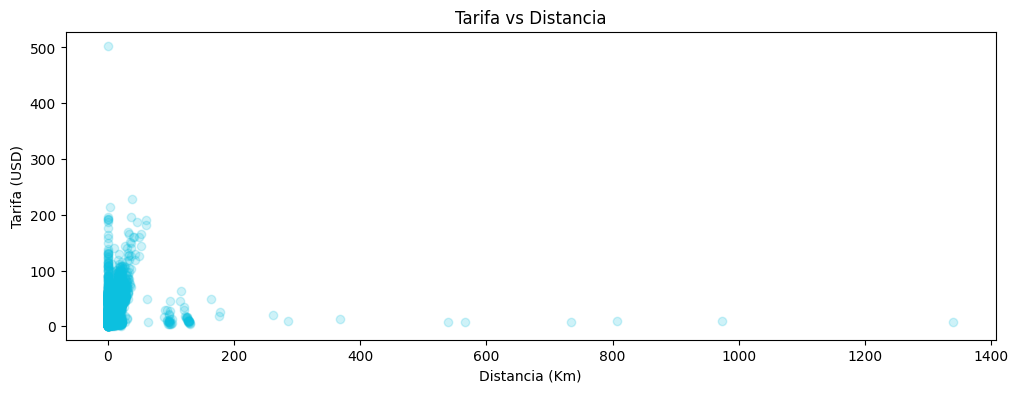

In [22]:
plt.figure(figsize=(12, 4))
plt.scatter(data["distance_km"], data["fare_amount"], alpha=0.2, color="#0cc0df")
plt.title("Tarifa vs Distancia")
plt.xlabel("Distancia (Km)")
plt.ylabel("Tarifa (USD)")
plt.show()

Tanto en los boxplots como en el scatter plot se ve que fare_amount y distance_km tienen valores bastante alejados del comportamiento general. En particular, aparecen viajes muy cortos con tarifas inusualmente altas y también viajes muy largos con tarifas relativamente bajas. Como estos casos pueden influir demasiado en el análisis y en el ajuste del modelo, vamos a tomar los valores por encima del percentil 99.5 como potenciales outliers y los vamos a eliminar en estas variables.

In [23]:
columnas = ["fare_amount", "distance_km"]

for col in columnas:
    limite = data[col].quantile(0.995)
    data = data[data[col] <= limite]

A continuación, se muestran los gráficos una vez aplicado este recorte, para ver con más claridad cómo queda la distribución de los datos.

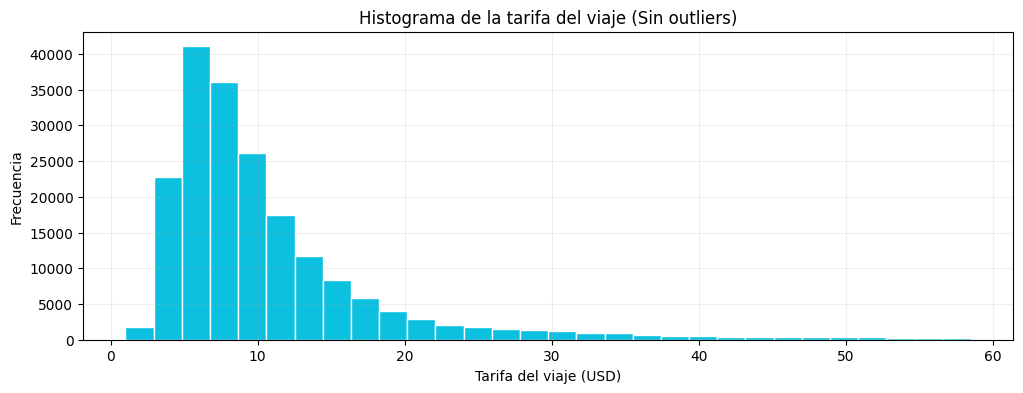

In [24]:
plt.figure(figsize=(12, 4))
data["fare_amount"].hist(bins=30, color="#0cc0df", edgecolor="#FFFFFF")
plt.grid(True, alpha=0.2)
plt.title("Histograma de la tarifa del viaje (Sin outliers)")
plt.xlabel("Tarifa del viaje (USD)")
plt.ylabel("Frecuencia")
plt.show()

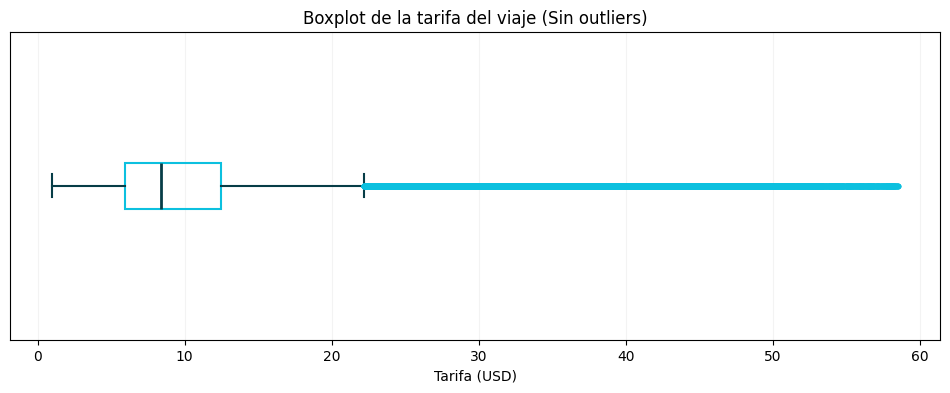

In [25]:
plt.figure(figsize=(12, 4))

plt.boxplot(
    data["fare_amount"].dropna(),
    orientation="horizontal",
    patch_artist=True,
    boxprops=dict(facecolor="none", edgecolor="#0cc0df", linewidth=1.5),
    medianprops=dict(color="#073D47", linewidth=2),
    whiskerprops=dict(color="#073D47", linewidth=1.5),
    capprops=dict(color="#073D47", linewidth=1.5),
    flierprops=dict(
        marker="o",
        markerfacecolor="none",
        markeredgecolor="#0cc0df",
        markeredgewidth=1,
        markersize=3,
        alpha=0.7
    )
)

plt.title("Boxplot de la tarifa del viaje (Sin outliers)")
plt.xlabel("Tarifa (USD)")
plt.yticks([])
plt.grid(True, axis="x", alpha=0.15)
plt.show()

In [26]:
data["fare_amount"].describe(percentiles=[.25, .50, .75, .95, .99])

count    193226.000000
mean         10.853793
std           8.212946
min           1.000000
25%           5.960000
50%           8.370000
75%          12.460000
95%          27.750000
99%          47.840000
max          58.510000
Name: fare_amount, dtype: float64

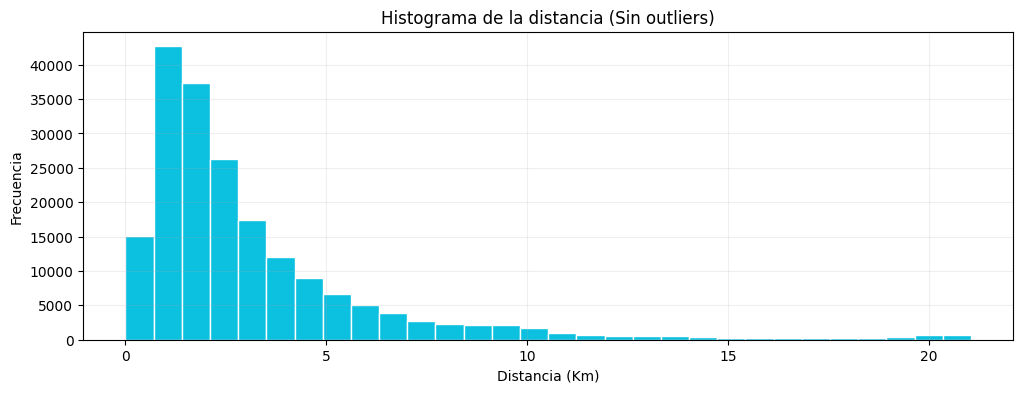

In [27]:
plt.figure(figsize=(12, 4))
data["distance_km"].hist(bins=30, color="#0cc0df", edgecolor="#FFFFFF")
plt.grid(True, alpha=0.2)
plt.title("Histograma de la distancia (Sin outliers)")
plt.xlabel("Distancia (Km)")
plt.ylabel("Frecuencia")
plt.show()

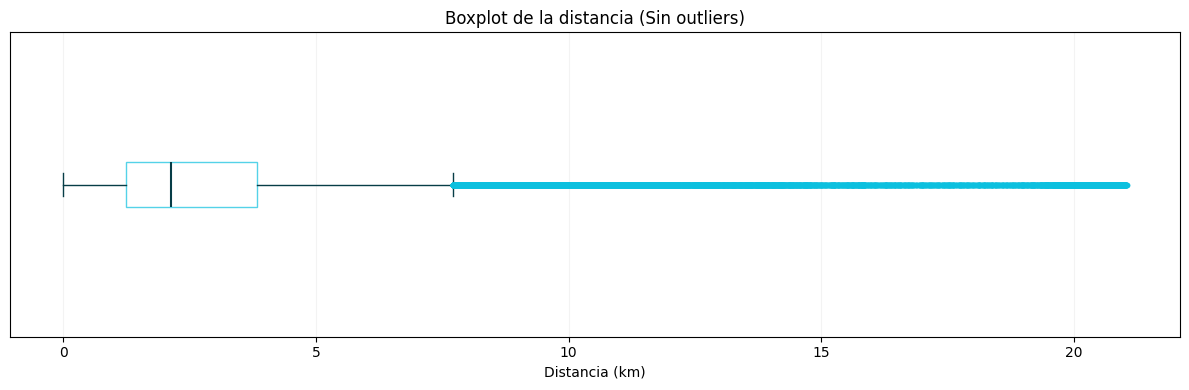

In [28]:
plt.figure(figsize=(12, 4))

plt.boxplot(
    data["distance_km"],
    orientation="horizontal",
    patch_artist=True,
    boxprops=dict(facecolor="none", edgecolor="#0cc0df", alpha=0.7),
    medianprops=dict(color="#073D47", linewidth=1.5),
    whiskerprops=dict(color="#073D47"),
    capprops=dict(color="#073D47"),
    flierprops=dict(
        marker="o",
        markerfacecolor="none",
        markeredgecolor="#0cc0df",
        markersize=3,
        alpha=0.5
    )
)

plt.title("Boxplot de la distancia (Sin outliers)")
plt.xlabel("Distancia (km)")
plt.yticks([])
plt.grid(True, axis="x", alpha=0.15)
plt.tight_layout()
plt.show()

In [29]:
data["distance_km"].describe(percentiles=[.25, .50, .75, .95, .99])

count    193226.000000
mean          3.159092
std           3.168786
min           0.000000
25%           1.249703
50%           2.138534
75%           3.833867
95%           9.430818
99%          18.211169
max          21.044396
Name: distance_km, dtype: float64

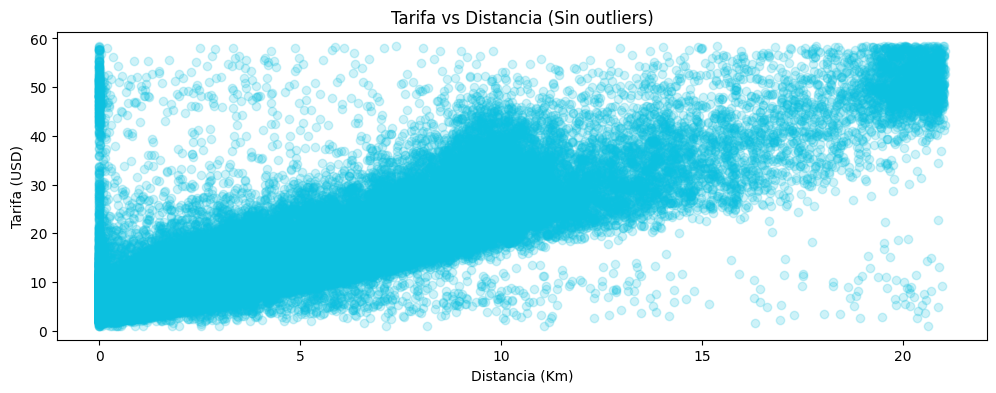

In [30]:
plt.figure(figsize=(12, 4))
plt.scatter(data["distance_km"], data["fare_amount"], alpha=0.2, color="#0cc0df")
plt.title("Tarifa vs Distancia (Sin outliers)")
plt.xlabel("Distancia (Km)")
plt.ylabel("Tarifa (USD)")
plt.show()

En general, después del recorte los datos quedan bastante más ordenados y fáciles de interpretar. Se reduce la presencia de valores extremos que distorsionaban la visualización y algunas métricas descriptivas, pero se conserva la forma general de las distribuciones. Esto hace que el conjunto de datos resulte más adecuado para las etapas que siguen del trabajo.

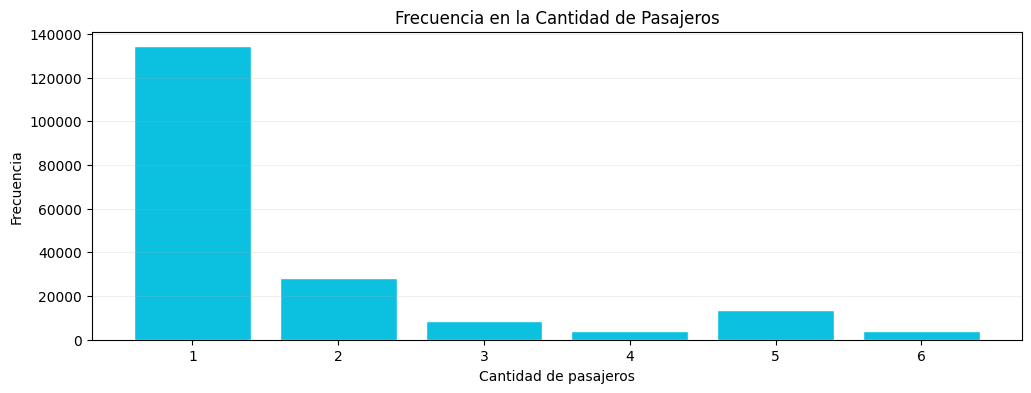

In [31]:
conteo = data["passenger_count"].value_counts().sort_index()

plt.figure(figsize=(12, 4))
plt.bar(conteo.index, conteo.values, color="#0cc0df", edgecolor="#FFFFFF")
plt.title("Frecuencia en la Cantidad de Pasajeros")
plt.xlabel("Cantidad de pasajeros")
plt.ylabel("Frecuencia")
plt.grid(True, axis="y", alpha=0.2)
plt.show()

En este gráfico podemos ver que hay una fuerte tendencia a los viajes individuales.

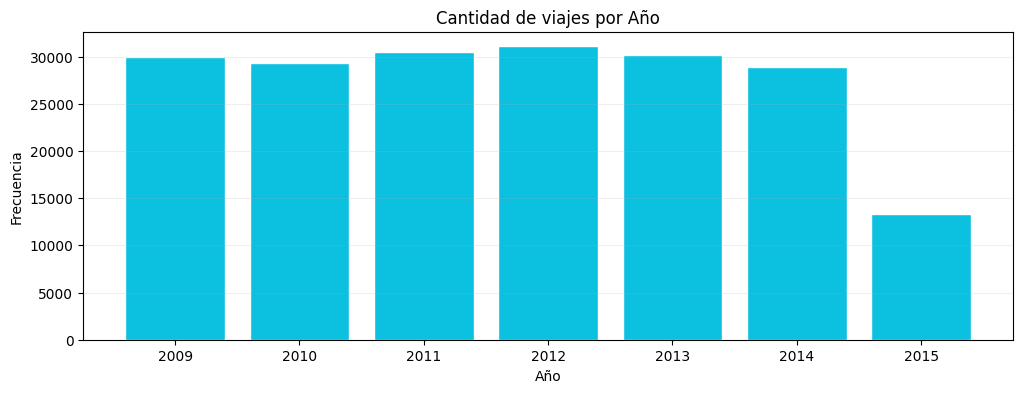

In [32]:
conteo = data["year"].value_counts().sort_index()

plt.figure(figsize=(12, 4))
plt.bar(conteo.index, conteo.values, color="#0cc0df", edgecolor="#FFFFFF")
plt.title("Cantidad de viajes por Año")
plt.xlabel("Año")
plt.ylabel("Frecuencia")
plt.grid(True, axis="y", alpha=0.2)
plt.show()

El dataset contiene información hasta mediados del 2015, por lo que para las evaluaciones correspondientes a los meses vamos a usar una copia del dataset que solo tome hasta 2014, así evitamos distribuciones sesgadas por la falta de datos. 

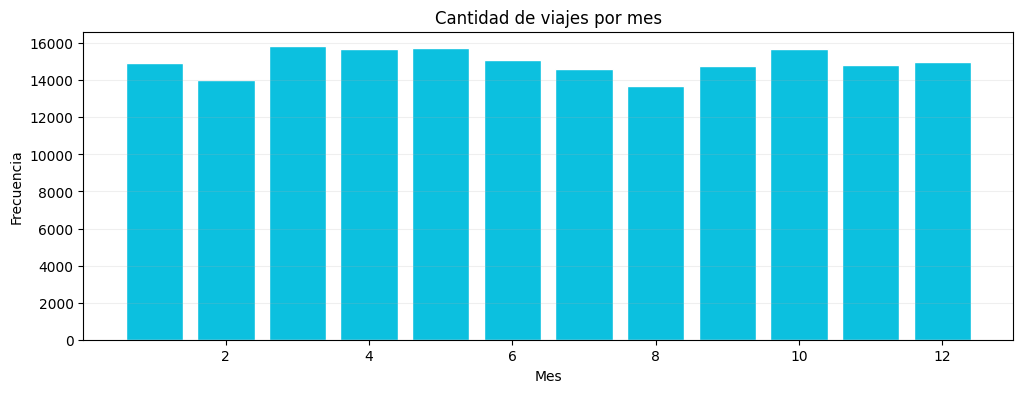

In [33]:
data_2014 = data[data["year"] < 2015].copy()

conteo = data_2014["month"].value_counts().sort_index()

plt.figure(figsize=(12, 4))
plt.bar(conteo.index, conteo.values, color="#0cc0df", edgecolor="#FFFFFF")
plt.title("Cantidad de viajes por mes")
plt.xlabel("Mes")
plt.ylabel("Frecuencia")
plt.grid(True, axis="y", alpha=0.2)
plt.show()

En este gráfico se ve que la cantidad de viajes no se mantiene igual a lo largo del año, sino que va cambiando según el mes aunque sea leve. Esto nos da la idea de que puede haber cierta estacionalidad en los datos. De todas formas, con esta visualización sola no podemos asegurar a qué se debe esa variación, aunque sí nos permite ver que el mes podría estar capturando algún patrón temporal interesante dentro del comportamiento de los viajes.

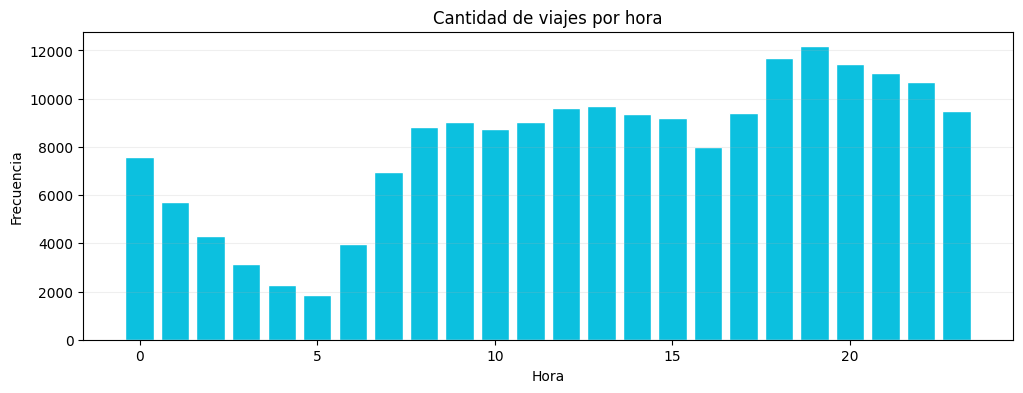

In [34]:
conteo = data["hour"].value_counts().sort_index()

plt.figure(figsize=(12, 4))
plt.bar(conteo.index, conteo.values, color="#0cc0df", edgecolor="#FFFFFF")
plt.title("Cantidad de viajes por hora")
plt.xlabel("Hora")
plt.ylabel("Frecuencia")
plt.grid(True, axis="y", alpha=0.2)
plt.show()

En este gráfico nos muestra que durante la madrugada hay menos viajes, sobre todo entre las 3 y las 6 de la mañana. A partir de ahí la cantidad empieza a subir y se mantiene alta durante buena parte del día, con un pico más marcado hacia la tarde-noche, cerca de las 18 y 19 horas. Esto nos da la idea de que la demanda de viajes cambia según la hora, y que 'hour' puede ser una variable importante para el análisis.

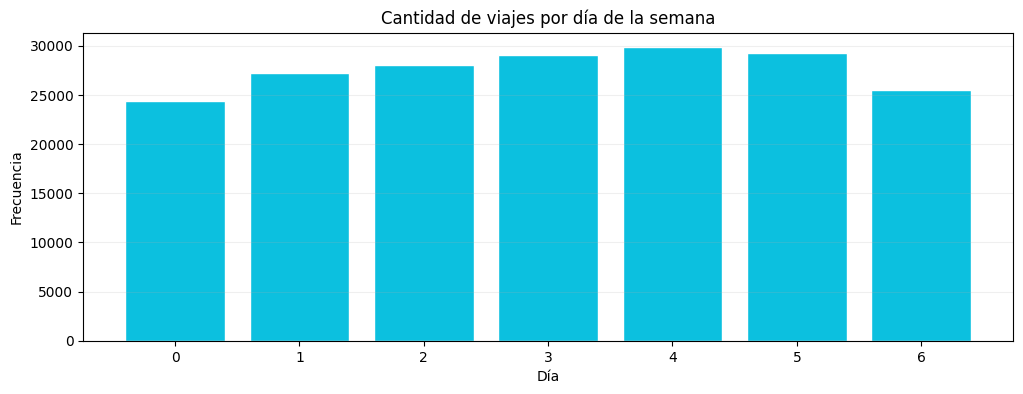

In [35]:
conteo = data["weekday"].value_counts().sort_index()

plt.figure(figsize=(12, 4))
plt.bar(conteo.index, conteo.values, color="#0cc0df", edgecolor="#FFFFFF")
plt.title("Cantidad de viajes por día de la semana")
plt.xlabel("Día")
plt.ylabel("Frecuencia")
plt.grid(True, axis="y", alpha=0.2)
plt.show()

En este caso vemos que si bien los Lunes (Día 0) hay una frecuencia menor, la cantidad de viajes por día se mantiene mayormente estable. 

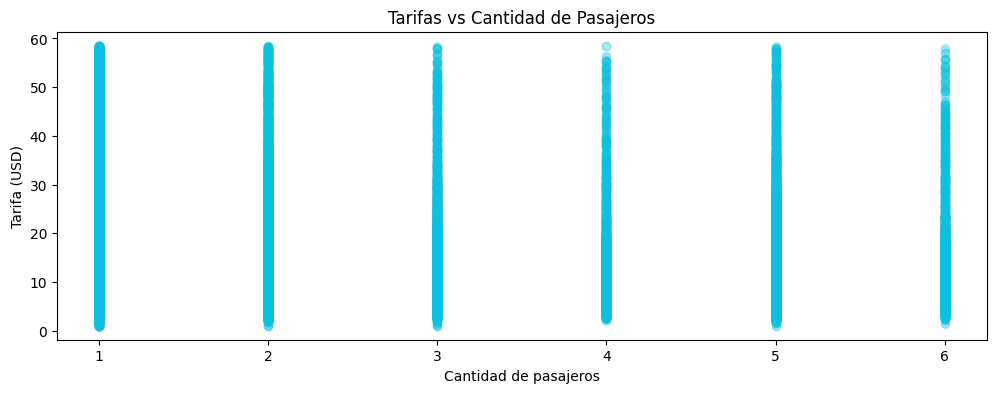

In [36]:
plt.figure(figsize=(12, 4))
plt.scatter(data["passenger_count"], data["fare_amount"], alpha=0.2, color="#0cc0df")
plt.title("Tarifas vs Cantidad de Pasajeros")
plt.xlabel("Cantidad de pasajeros")
plt.ylabel("Tarifa (USD)")
plt.show()

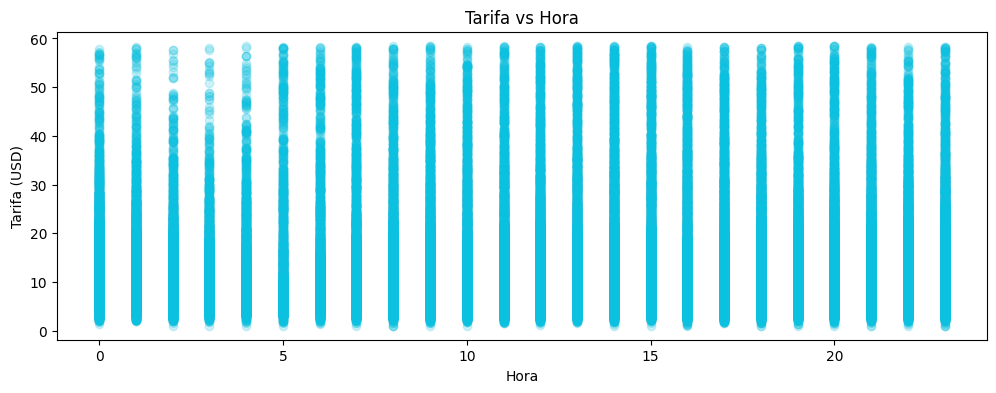

In [37]:
plt.figure(figsize=(12, 4))
plt.scatter(data["hour"], data["fare_amount"], alpha=0.2, color="#0cc0df")
plt.title("Tarifa vs Hora")
plt.xlabel("Hora")
plt.ylabel("Tarifa (USD)")
plt.show()

En estos gráficos no se observa una relación clara entre la cantidad de pasajeros o la hora a la que se realizó el viaje con la tarifa. 

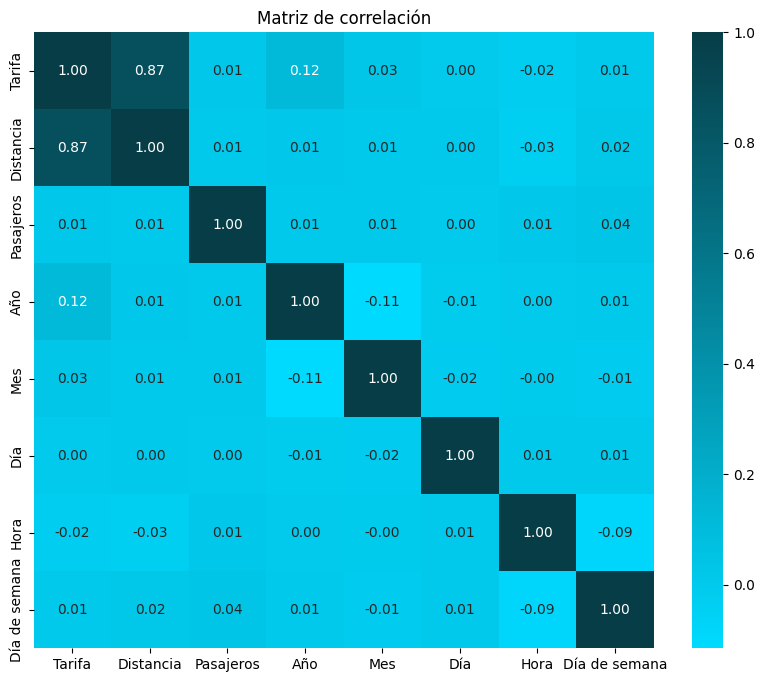

In [38]:
corr_cols = [
    "fare_amount",
    "distance_km",
    "passenger_count",
    "year",
    "month",
    "day",
    "hour",
    "weekday"
]

corr = data[corr_cols].corr(numeric_only=True)

nombres = {
    "fare_amount": "Tarifa",
    "distance_km": "Distancia",
    "passenger_count": "Pasajeros",
    "year": "Año",
    "month": "Mes",
    "day": "Día",
    "hour": "Hora",
    "weekday": "Día de semana"
}

corr = corr.rename(index=nombres, columns=nombres)

cmap_personalizado = LinearSegmentedColormap.from_list(
    "mi_cmap",
    ["#00daff", "#073D47"]
)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap=cmap_personalizado, fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

En la matriz de correlación se ve bastante claro que la variable con mayor relación lineal con la tarifa es la distancia, con una correlación alta y positiva. Esto era esperable, ya que a mayor distancia recorrida, mayor tiende a ser el costo del viaje. En cambio, el resto de las variables muestran correlaciones bastante bajas con la tarifa, por lo que, al menos de manera lineal, no parecen tener un peso tan fuerte por sí solas.

In [39]:
print(data.shape)

(193226, 14)


A lo largo del análisis detectamos valores faltantes (en dropoff), cantidades de pasajeros no lógicas (0 o 208), coordenadas inexistentes o fuera del rango de interés y algunos valores extremos que podían sumar ruido en variables importantes como la tarifa y la distancia. 

Después de aplicar esta limpieza, pasamos de 200.000 registros a 193.226, es decir, se eliminaron 6.774 filas, que representan alrededor del 3,39% del total. Esto nos deja una base bastante más consistente para seguir trabajando, sin haber perdido una parte grande de la información original.

A su vez, los gráficos y las medidas descriptivas posteriores al recorte nos permiten ver los datos de una forma mucho más clara, y la matriz de correlación termina de resumir qué variables parecen estar más vinculadas con la tarifa. 

Con todo esto, el conjunto de datos final es más consistente y está correctamente preparado para avanzar con la parte de modelado.

## Modelado

Para empezar con la etapa de modelado, armamos un nuevo dataframe que contiene únicamente las variables que vamos a usar como predictoras. En este caso decidimos dejar afuera 'key', porque funciona solo como identificador y no aporta información útil sobre el viaje, y también 'timezone', ya que es igual en todos los registros y no suma nada al análisis.

Por otro lado, se optó por no incluir 'day', porque dentro del análisis exploratorio no mostró una relación especialmente clara con la tarifa y consideramos que podía agregar más ruido que información al modelo. De esta forma, nos quedamos con variables que mejor representan el problema y que tienen más sentido para intentar predecir la tarifa.

In [40]:
modelo = data.drop(columns = ["key","timezone","day"])
x = modelo.drop(columns = ["fare_amount"])
y = modelo["fare_amount"]

In [41]:
modelo.columns

Index(['fare_amount', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'passenger_count', 'year',
       'month', 'hour', 'weekday', 'distance_km'],
      dtype='str')

In [42]:
# Se realiza el split train/test, tomando el 20% de los datos para test.

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=66)

print("X_train:", x_train.shape)
print("X_test :", x_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (154580, 10)
X_test : (38646, 10)
y_train: (154580,)
y_test : (38646,)


In [43]:
# Realizamos los dummies de las variables categóricas

x_train = pd.get_dummies(x_train, columns=["month", "weekday", "hour"], drop_first=True)
x_test  = pd.get_dummies(x_test,  columns=["month", "weekday", "hour"], drop_first=True)

x_train, x_test = x_train.align(x_test, join="left", axis=1, fill_value=0)

In [44]:
# Escalado de los datos.

scaler = StandardScaler()

x_train_escalado = scaler.fit_transform(x_train)
x_test_escalado = scaler.transform(x_test)

print(x_train_escalado.shape)
print(x_test_escalado.shape)

(154580, 47)
(38646, 47)


In [45]:
# Funciones auxiliares para la evaluación de modelos.

def calcular_metricas(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return {
        "R2": r2,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae
    }

def resumen_metricas(nombre_modelo, y_train, y_pred_train, y_test, y_pred_test):
    metricas_train = calcular_metricas(y_train, y_pred_train)
    metricas_test = calcular_metricas(y_test, y_pred_test)

    resumen = pd.DataFrame({
        "Train": metricas_train,
        "Test": metricas_test
    })

    print(f"Métricas del modelo: {nombre_modelo}")
    return resumen

def grafico_residuos(y_true, y_pred, titulo):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    residuos = y_true - y_pred

    plt.figure(figsize=(8, 5))
    plt.scatter(y_pred, residuos, alpha=0.3)
    plt.axhline(y=0, color="red", linestyle="--")
    plt.title(titulo)
    plt.xlabel("Valores predichos")
    plt.ylabel("Residuos")
    plt.grid(alpha=0.2)
    plt.show()

In [46]:
# Modelo de Regresión Lineal Múltiple
modelo_lr = LinearRegression()
modelo_lr.fit(x_train_escalado, y_train)

y_pred_train_lr = modelo_lr.predict(x_train_escalado)
y_pred_test_lr = modelo_lr.predict(x_test_escalado)

print("Intercepto:")
print(modelo_lr.intercept_)

tabla_metricas_lr = resumen_metricas(
    "Regresión Lineal Múltiple",
    y_train,
    y_pred_train_lr,
    y_test,
    y_pred_test_lr
)

tabla_metricas_lr

Intercepto:
10.852114245051055
Métricas del modelo: Regresión Lineal Múltiple


,Train,Test
R2,0.778012,0.782317
MSE,14.967212,14.708153
RMSE,3.868748,3.835121
MAE,2.193354,2.183219


El modelo de regresión lineal múltiple obtuvo valores de R² cercanos a 0.78 tanto en entrenamiento como en prueba, lo que indica que logra explicar una parte importante de la variabilidad de la tarifa. Además, las métricas de error son muy parecidas en ambos conjuntos, por lo que no se observan diferencias grandes entre el desempeño en train y en test. En principio, esto sugiere que el modelo generaliza bastante bien y que no hay señales claras de sobreajuste.

In [47]:
coeficientes_lr = pd.DataFrame({
    "Variable": x_train.columns,
    "Coeficiente": modelo_lr.coef_
}).sort_values(by="Coeficiente", key=np.abs, ascending=False)

coeficientes_lr.head(15)

,Variable,Coeficiente
6,distance_km,6.951478
5,year,0.883384
3,dropoff_latitude,-0.507940
0,pickup_longitude,0.457170
37,hour_14,0.275137
35,hour_12,0.273036
38,hour_15,0.261963
36,hour_13,0.260314
34,hour_11,0.244493
40,hour_17,0.236564


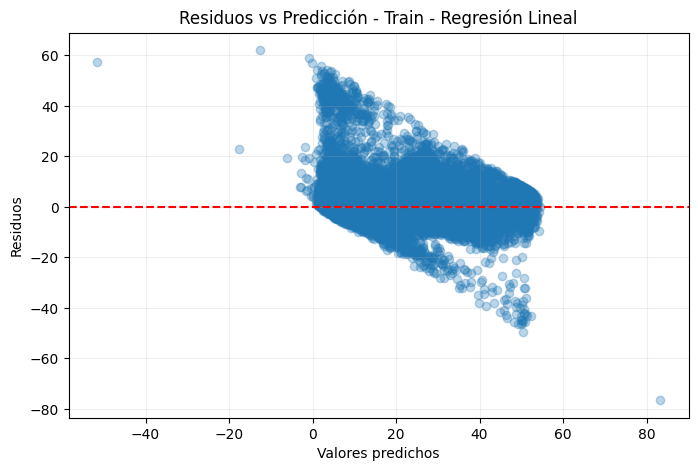

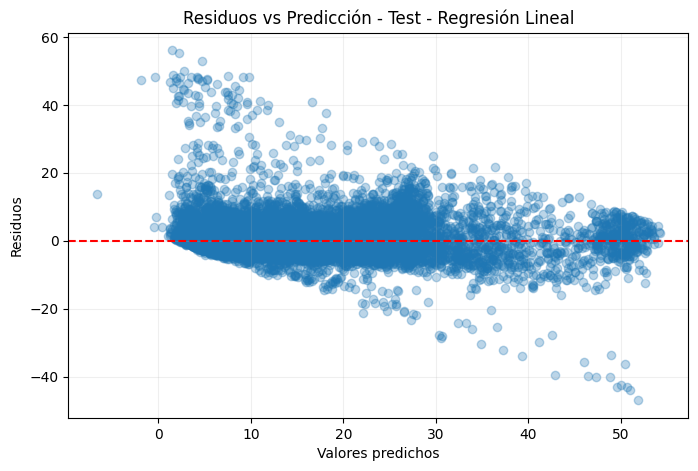

In [48]:
grafico_residuos(
    y_train,
    y_pred_train_lr,
    "Residuos vs Predicción - Train - Regresión Lineal"
)

grafico_residuos(
    y_test,
    y_pred_test_lr,
    "Residuos vs Predicción - Test - Regresión Lineal"
)

Los gráficos de residuos muestran que el modelo lineal logra un ajuste razonable, aunque no perfecto. En general, los errores se mantienen alrededor de cero y el comportamiento entre entrenamiento y prueba es bastante parecido, lo que vuelve a indicar que el modelo generaliza de forma estable.

De todas formas, los residuos no se distribuyen de manera completamente aleatoria: en ambos gráficos aparece cierto patrón, especialmente en los extremos, donde se ve que el modelo tiende a sobreestimar algunos viajes de menor valor y a subestimar otros de mayor tarifa. Esto sugiere que, si bien la regresión lineal captura una parte importante de la relación entre las variables, no llega a explicar por completo toda la variabilidad presente en los datos.

Tiene sentido que pase esto, porque más allá de variables como la distancia, la hora o el mes, hay otros factores que también pueden influir en el precio del viaje y que no están incluidos en el dataset, como la demanda del momento, el tráfico, el clima o el tipo de zona en la que se realiza el recorrido.

In [49]:
    def gradient_descent(X_train, y_train, X_val, y_val, lr=0.01, epochs=100):
        """
        shapes:
            X_train = nxm
            y_train = nx1
            X_val = pxm
            y_val = px1
            W_gd = mx1
        """
        
        n = X_train.shape[0]
        m = X_train.shape[1]
        o = X_val.shape[0]

        X_train = np.hstack((np.ones((n, 1)), X_train))
        X_val = np.hstack((np.ones((o, 1)), X_val))

        W_gd = np.random.randn(m + 1).reshape(m + 1, 1)

        train_errors = []
        test_errors = []

        for _ in range(epochs):
            prediction_train = np.matmul(X_train, W_gd)
            error_train = y_train - prediction_train
            train_mse = np.mean(error_train ** 2)
            train_errors.append(train_mse)

            prediction_test = np.matmul(X_val, W_gd)
            error_test = y_val - prediction_test
            test_mse = np.mean(error_test ** 2)
            test_errors.append(test_mse)

            grad_sum = np.sum(error_train * X_train, axis=0)
            grad_mul = -2 / n * grad_sum
            gradient = np.transpose(grad_mul).reshape(-1, 1)

            W_gd = W_gd - (lr * gradient)

        plt.figure(figsize=(12, 6))
        plt.plot(train_errors, label='Error de entrenamiento', color="#003049")
        plt.plot(test_errors, label='Error de validación', color="#00daff")
        plt.xlabel('Época')
        plt.ylabel('Error cuadrático medio')
        plt.legend()
        plt.title('Error de entrenamiento y validación VS iteraciones (GD)')
        plt.show()

        return W_gd, train_errors, test_errors

In [50]:
def stochastic_gradient_descent(X_train, y_train, X_test, y_test, lr=0.01, epochs=100):
    n = X_train.shape[0]
    m = X_train.shape[1]

    X_train_bias = np.hstack((np.ones((n, 1)), X_train))
    X_test_bias = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

    W_sgd = np.random.randn(m + 1).reshape(-1, 1)

    train_errors = []
    test_errors = []

    for i in range(epochs):
        permutation = np.random.permutation(n)
        X_train_shuffled = X_train_bias[permutation]
        y_train_shuffled = y_train[permutation]

        for j in range(n):
            x_sample = X_train_shuffled[j].reshape(1, -1)
            y_sample = y_train_shuffled[j].reshape(1, 1)

            prediction = np.matmul(x_sample, W_sgd)
            error = y_sample - prediction

            gradient = -2 * np.matmul(x_sample.T, error)
            W_sgd = W_sgd - (lr * gradient)

        prediction_train = np.matmul(X_train_bias, W_sgd)
        error_train = y_train - prediction_train
        train_mse = np.mean(error_train ** 2)
        train_errors.append(train_mse)

        prediction_test = np.matmul(X_test_bias, W_sgd)
        error_test = y_test - prediction_test
        test_mse = np.mean(error_test ** 2)
        test_errors.append(test_mse)

    plt.figure(figsize=(12, 6))
    plt.plot(train_errors, label='Error de entrenamiento', color="#003049")
    plt.plot(test_errors, label='Error de prueba', color="#00daff")
    plt.xlabel('Época')
    plt.ylabel('Error cuadrático medio')
    plt.legend()
    plt.title('Error de entrenamiento y prueba vs iteraciones (SGD)')
    plt.ylim(0, 100)  # pequeña trampilla hecha para que los graficos no se ensucien
    plt.show()
    
    return W_sgd, train_errors, test_errors

En el caso de Stochastic Gradient Descent, fue necesario hacer algunos ajustes sobre la implementación trabajada en clase para que el entrenamiento resultara más razonable en términos de tiempo y más claro al momento de analizar las curvas.

Se mantuvo la lógica propia del método, es decir, la actualización de los pesos muestra por muestra, pero el cálculo del error de entrenamiento y validación pasó a realizarse una sola vez por época y no en cada actualización interna. Además, en cada época se trabaja con una versión mezclada del conjunto de entrenamiento y cada muestra se reacomoda de forma explícita para mantener consistencia matricial al calcular la predicción y el gradiente.

Con estos cambios, el algoritmo conserva el comportamiento estocástico, pero se vuelve mucho más manejable en tiempo de ejecución y permite obtener curvas de error más limpias y comparables con las de los otros métodos.

In [51]:
def mini_batch_gradient_descent(X_train, y_train, X_test, y_test, lr=0.01, epochs=100, batch_size=11):
    n = X_train.shape[0]
    m = X_train.shape[1]

    X_train_bias = np.hstack((np.ones((n, 1)), X_train))
    X_test_bias = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

    W_mbgd = np.random.randn(m + 1).reshape(-1, 1)

    train_errors = []
    test_errors = []

    for i in range(epochs):
        permutation = np.random.permutation(n)
        X_train_shuffled = X_train_bias[permutation]
        y_train_shuffled = y_train[permutation]

        for j in range(0, n, batch_size):
            x_batch = X_train_shuffled[j:j + batch_size, :]
            y_batch = y_train_shuffled[j:j + batch_size].reshape(-1, 1)

            prediction_batch = np.matmul(x_batch, W_mbgd)
            error_batch = y_batch - prediction_batch

            batch_n = x_batch.shape[0]
            gradient = -2 * np.matmul(x_batch.T, error_batch) / batch_n

            W_mbgd = W_mbgd - (lr * gradient)

        # Error de entrenamiento al final de la época
        prediction_train = np.matmul(X_train_bias, W_mbgd)
        error_train = y_train.reshape(-1, 1) - prediction_train
        train_mse = np.mean(error_train ** 2)
        train_errors.append(train_mse)

        # Error de prueba al final de la época
        prediction_test = np.matmul(X_test_bias, W_mbgd)
        error_test = y_test.reshape(-1, 1) - prediction_test
        test_mse = np.mean(error_test ** 2)
        test_errors.append(test_mse)

    plt.figure(figsize=(12, 6))
    plt.plot(train_errors, label='Error de entrenamiento', color="#003049")
    plt.plot(test_errors, label='Error de prueba', color="#00daff")
    plt.xlabel('Época')
    plt.ylabel('Error cuadrático medio')
    plt.legend()
    plt.title('Error de entrenamiento y prueba vs épocas (Mini-Batch GD)')
    plt.ylim(0, 100)
    plt.show()

    return W_mbgd, train_errors, test_errors

Antes de continuar, se hizo un pequeño ajuste sobre la función trabajada en clase para que guarde el error por época y no por cada iteración interna. De esta forma, las curvas quedan más comparables entre los distintos métodos de descenso por gradiente y resultan más fáciles de interpretar.

A partir de esto, se implementan los tres enfoques: Gradient Descent, Stochastic Gradient Descent y Mini-Batch Gradient Descent.

Además, en algunos gráficos se fijó un límite superior de 100 en el eje vertical del MSE. Esto se hizo porque en ciertas pruebas aparecían valores muy altos en algunas épocas, lo que hacía que las curvas quedaran demasiado estiradas y perdieran legibilidad. Al acotar el eje, se puede observar con más claridad la variación del error en el rango donde la comparación resulta más útil.

In [52]:
X_train_gd, X_val_gd, y_train_gd, y_val_gd = train_test_split(
    x_train_escalado,
    y_train,
    test_size=0.125,
    random_state=42
)

X_train_gd = np.asarray(X_train_gd, dtype=float)
X_val_gd = np.asarray(X_val_gd, dtype=float)
y_train_gd = np.asarray(y_train_gd, dtype=float).reshape(-1, 1)
y_val_gd = np.asarray(y_val_gd, dtype=float).reshape(-1, 1)
y_test_gd = np.asarray(y_test, dtype=float).reshape(-1, 1)

print(X_train_gd.shape, y_train_gd.shape)
print(X_val_gd.shape, y_val_gd.shape)

(135257, 47) (135257, 1)
(19323, 47) (19323, 1)


Para poder ajustar los hiperparámetros de los métodos de descenso por gradiente sin usar directamente el conjunto de prueba, se separa una parte del conjunto de entrenamiento y se la toma como validación. De esta forma, el modelo se entrena sobre una porción de los datos y se evalúa sobre otra distinta durante esta etapa, dejando el conjunto de test reservado para la evaluación final.

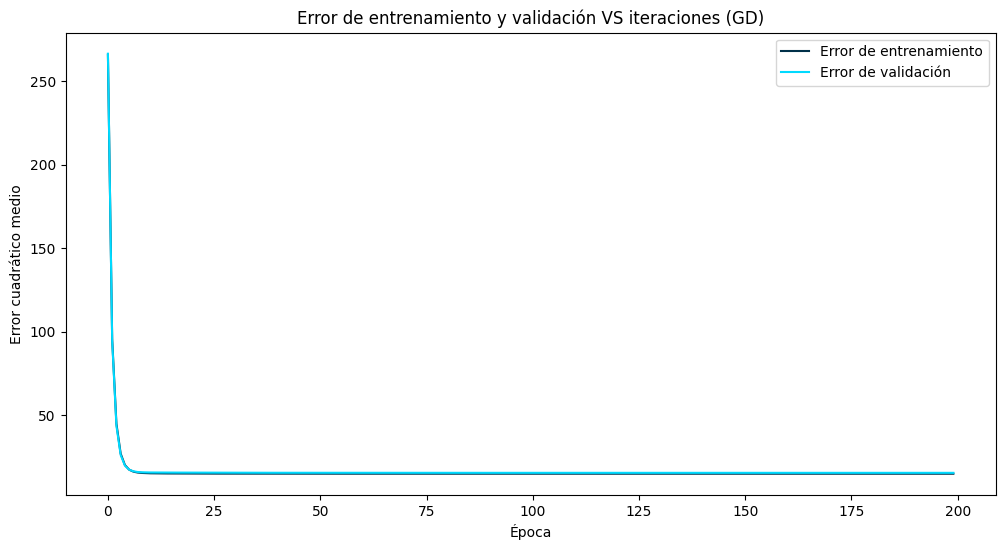

lr = 0.2
Mejor validación MSE: 15.432770228640683
Mejor época: 200
----------------------------------------


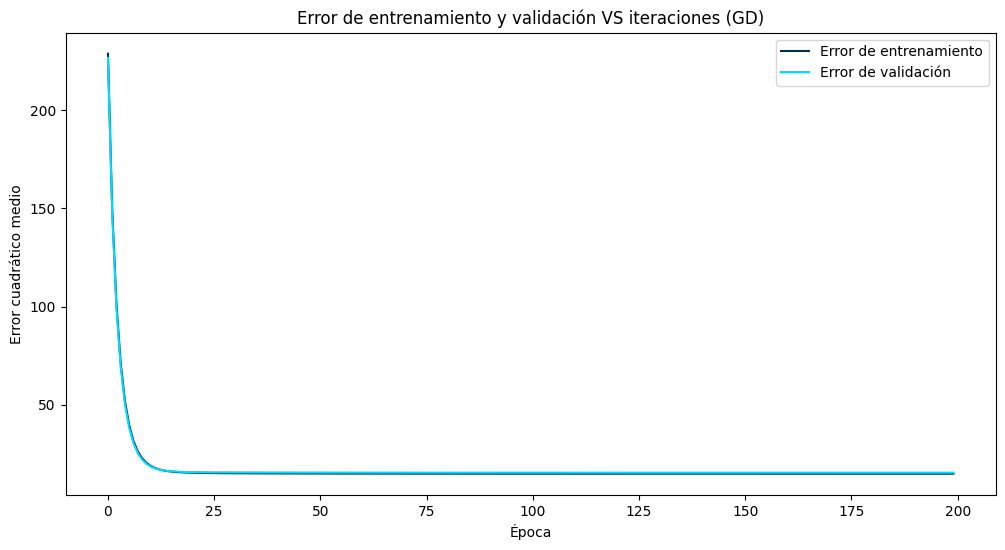

lr = 0.1
Mejor validación MSE: 15.43282852207319
Mejor época: 200
----------------------------------------


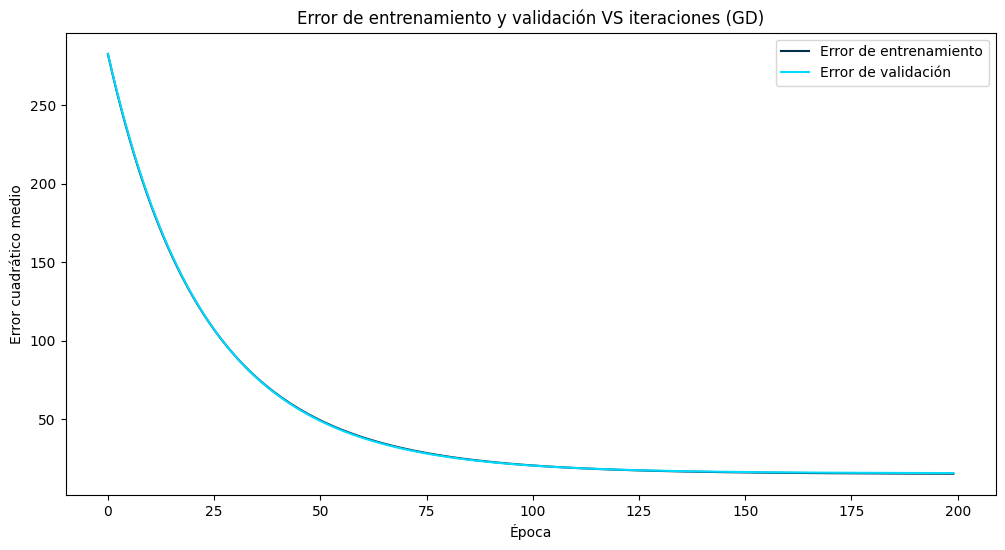

lr = 0.01
Mejor validación MSE: 15.739197483670758
Mejor época: 200
----------------------------------------


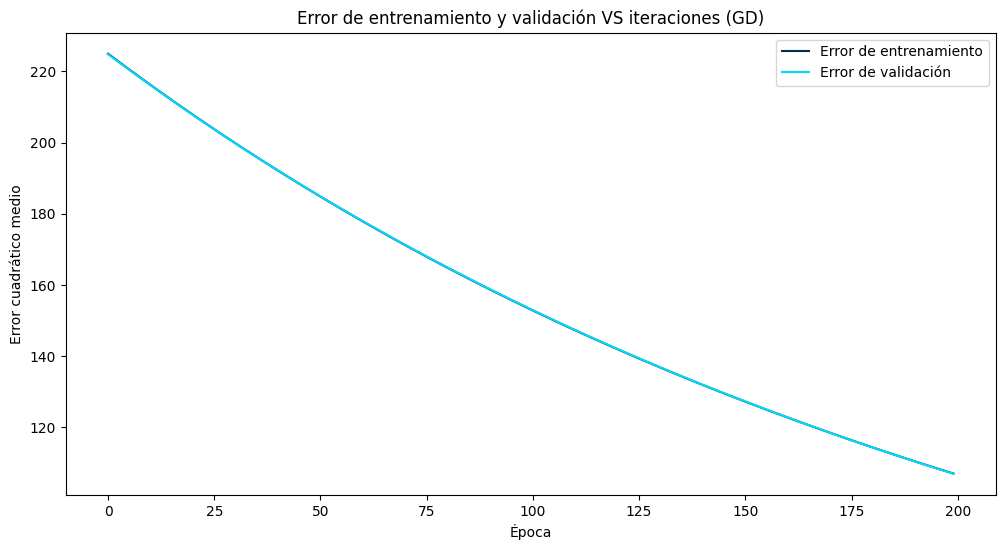

lr = 0.001
Mejor validación MSE: 106.95075143527959
Mejor época: 200
----------------------------------------


In [53]:
lrs = [0.2, 0.1, 0.01, 0.001]
resultados_gd = {}

for lr in lrs:
    W_gd, train_errors, val_errors = gradient_descent(
        X_train_gd, y_train_gd,
        X_val_gd, y_val_gd,
        lr=lr,
        epochs=200
    )

    resultados_gd[lr] = {
        "W_gd": W_gd,
        "train_errors": train_errors,
        "val_errors": val_errors,
        "mejor_val_mse": min(val_errors),
        "mejor_epoch": np.argmin(val_errors) + 1
    }

    print(f"lr = {lr}")
    print(f"Mejor validación MSE: {min(val_errors)}")
    print(f"Mejor época: {np.argmin(val_errors) + 1}")
    print("-" * 40)

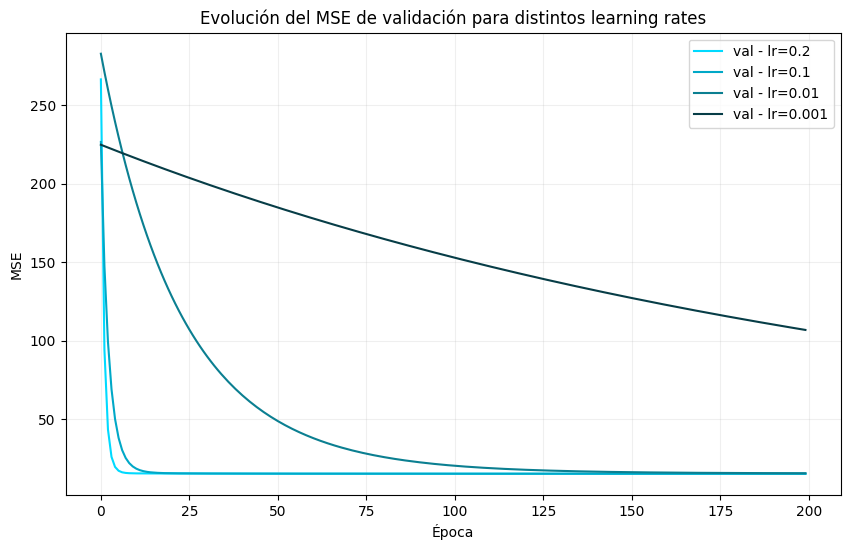

In [54]:
colores = ["#00daff", "#00a8c7", "#0b7f91", "#073D47"]
plt.figure(figsize=(10, 6))

for i, lr in enumerate(lrs):
    plt.plot(resultados_gd[lr]["val_errors"], label=f"val - lr={lr}", color=colores[i])

plt.xlabel("Época")
plt.ylabel("MSE")
plt.title("Evolución del MSE de validación para distintos learning rates")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

Comparando las curvas en conjunto, se ve que los learning rates más altos permiten una convergencia mucho más rápida, mientras que con valores más bajos el descenso del error es bastante más lento. En particular, lr = 0.001 no alcanza una zona estable comparable dentro de las 200 épocas analizadas, mientras que lr = 0.2 y lr = 0.1 llegan a valores bajos en pocas épocas. A partir de esto, se decide continuar con lr = 0.2, ya que logra la convergencia más rápida y obtiene el mejor MSE de validación dentro de los valores probados.

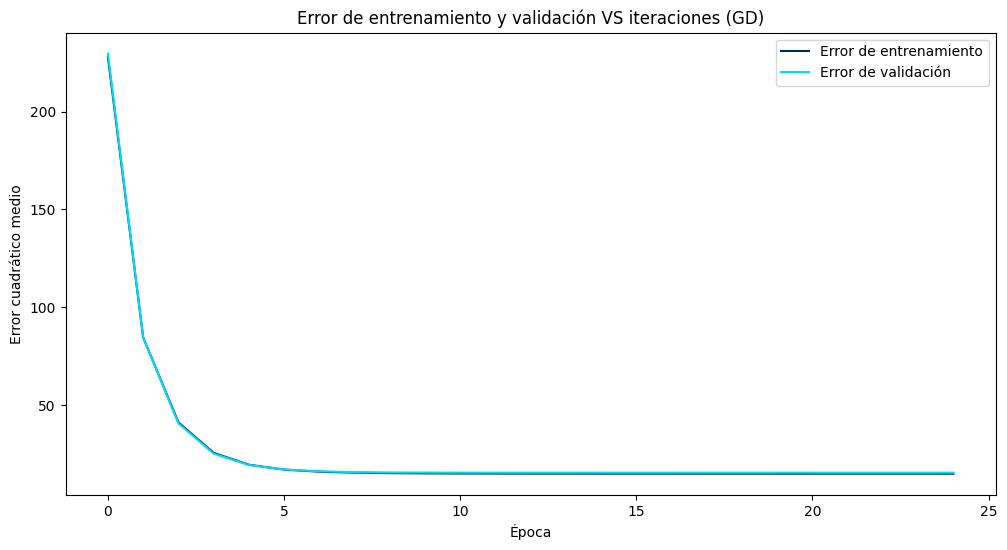

In [55]:
W_gd, train_errors_gd, val_errors_gd = gradient_descent(
    X_train_gd, y_train_gd,
    X_val_gd, y_val_gd,
    lr=0.2,
    epochs=25
)

En este gráfico se ve que, una vez elegido el learning rate, tanto el error de entrenamiento como el de validación bajan muy rápido en las primeras épocas y después se estabilizan en valores bastante parecidos. Esto sugiere que el modelo logra converger de forma estable y que no aparecen diferencias grandes entre ambos conjuntos en esta etapa. A partir de esto, tiene sentido seguir con estos hiperparámetros y pasar a revisar las métricas obtenidas.

In [56]:
X_train_gd_bias = np.hstack((np.ones((X_train_gd.shape[0], 1)), X_train_gd))
X_test_gd_bias = np.hstack((np.ones((x_test_escalado.shape[0], 1)), x_test_escalado))

y_pred_train_gd = np.matmul(X_train_gd_bias, W_gd).ravel()
y_pred_test_gd = np.matmul(X_test_gd_bias, W_gd).ravel()

tabla_metricas_gd = resumen_metricas(
    "Gradient Descent",
    y_train_gd.ravel(),
    y_pred_train_gd,
    y_test_gd.ravel(),
    y_pred_test_gd
)

tabla_metricas_gd

Métricas del modelo: Gradient Descent


,Train,Test
R2,0.778226,0.781882
MSE,14.920267,14.737590
RMSE,3.862676,3.838957
MAE,2.192103,2.186618


Con los hiperparámetros elegidos, el modelo muestra un desempeño bastante parejo entre los conjuntos comparados, por lo que en esta etapa no se observan diferencias grandes que hagan pensar en un sobreajuste marcado. Además, logra explicar alrededor del 78,1% de la variabilidad de la tarifa y presenta un RMSE cercano a 3,8 USD, lo que da una idea del error típico de predicción.

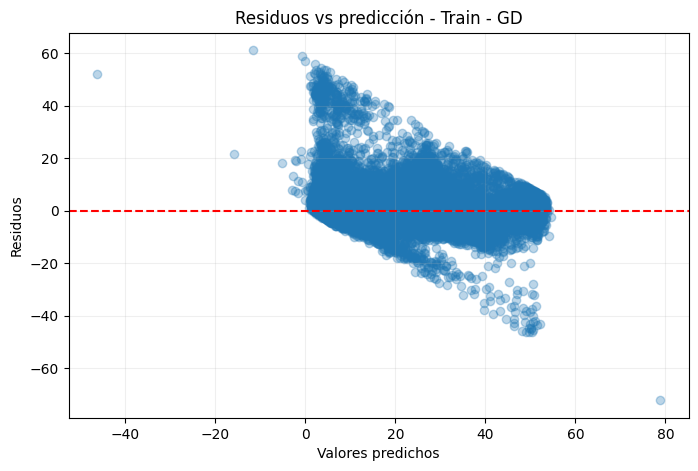

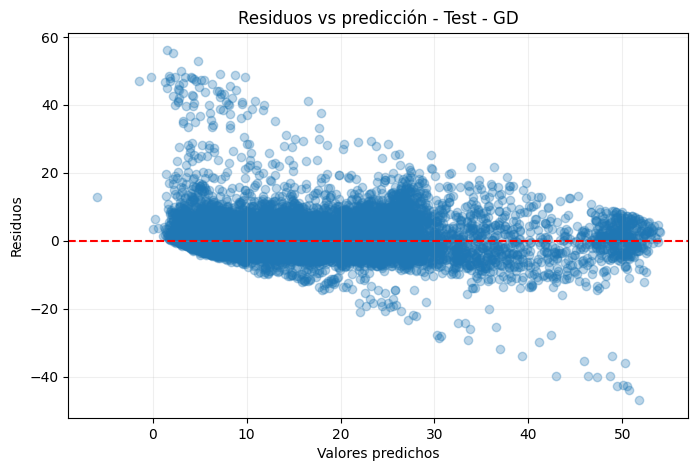

In [57]:
grafico_residuos(
    y_train_gd.ravel(),
    y_pred_train_gd,
    "Residuos vs predicción - Train - GD"
)

grafico_residuos(
    y_test_gd.ravel(),
    y_pred_test_gd,
    "Residuos vs predicción - Test - GD"
)

Los gráficos de residuos muestran un comportamiento bastante parecido al que se veía en la regresión lineal múltiple. Los errores siguen concentrándose alrededor de cero, pero todavía aparecen ciertos patrones y una dispersión que no es completamente aleatoria, sobre todo en algunos extremos. Esto sugiere que el modelo mantiene un ajuste razonable, aunque sigue sin captar por completo toda la variabilidad de los datos.

E:\temp\ipykernel_10992\363876108.py:30: RuntimeWarning: overflow encountered in square
  train_mse = np.mean(error_train ** 2)
E:\temp\ipykernel_10992\363876108.py:35: RuntimeWarning: overflow encountered in square
  test_mse = np.mean(error_test ** 2)
E:\temp\ipykernel_10992\363876108.py:25: RuntimeWarning: overflow encountered in multiply
  gradient = -2 * np.matmul(x_sample.T, error)
E:\temp\ipykernel_10992\363876108.py:26: RuntimeWarning: invalid value encountered in subtract
  W_sgd = W_sgd - (lr * gradient)
E:\temp\ipykernel_10992\363876108.py:22: RuntimeWarning: invalid value encountered in matmul
  prediction = np.matmul(x_sample, W_sgd)


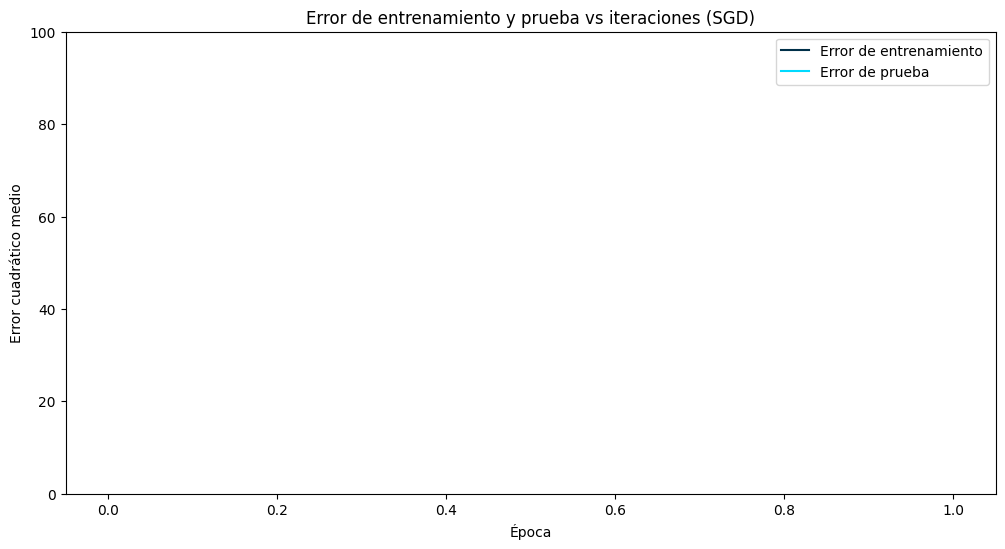

lr = 0.01
Mejor validación MSE: 5.186991893183622e+129
Mejor época: 5
----------------------------------------


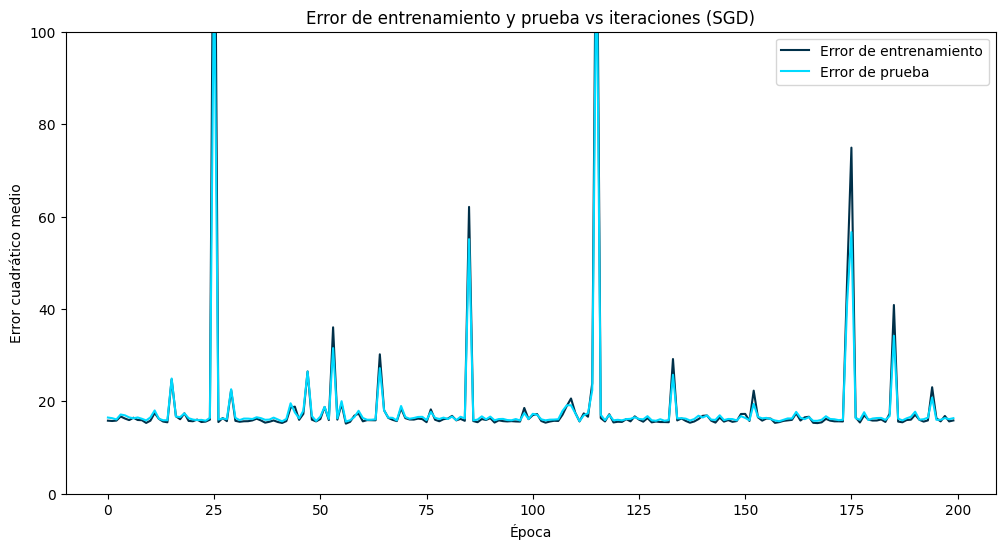

lr = 0.001
Mejor validación MSE: 15.609586300494476
Mejor época: 57
----------------------------------------


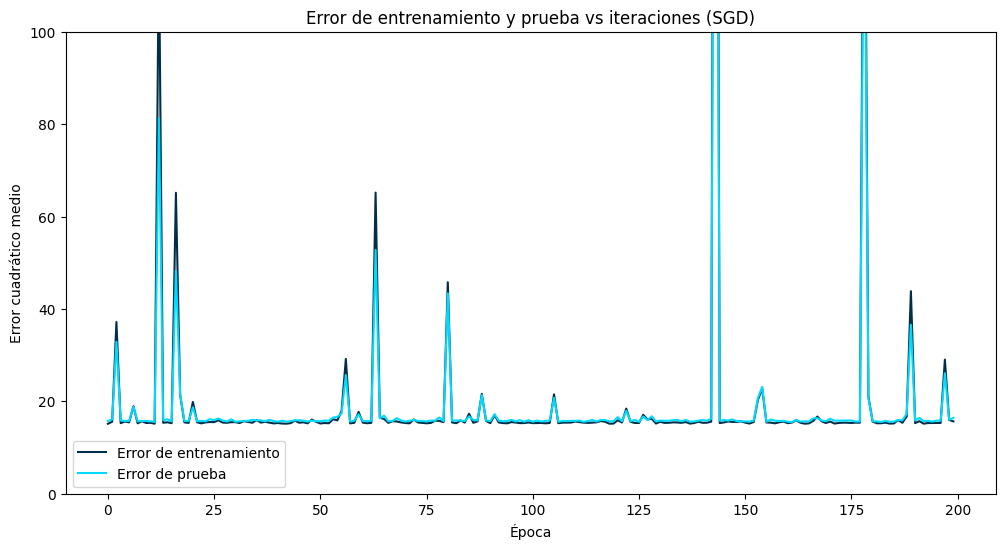

lr = 0.0005
Mejor validación MSE: 15.519316131871301
Mejor época: 162
----------------------------------------


In [58]:
lrs_sgd = [0.01, 0.001, 0.0005]
resultados_sgd = {}

for lr in lrs_sgd:
    W_sgd, train_errors, val_errors = stochastic_gradient_descent(
        X_train_gd, y_train_gd,
        X_val_gd, y_val_gd,
        lr=lr,
        epochs=200
    )

    resultados_sgd[lr] = {
        "W_sgd": W_sgd,
        "train_errors": train_errors,
        "val_errors": val_errors,
        "mejor_val_mse": min(val_errors),
        "mejor_epoch": np.argmin(val_errors) + 1
    }

    print(f"lr = {lr}")
    print(f"Mejor validación MSE: {min(val_errors)}")
    print(f"Mejor época: {np.argmin(val_errors) + 1}")
    print("-" * 40)

En SGD se observa un comportamiento más ruidoso que en GD, algo esperable por la forma en la que se actualizan los pesos. Con lr = 0.01 el entrenamiento se vuelve inestable, por lo que ese valor se descarta. En cambio, lr = 0.001 y lr = 0.0005 muestran curvas más razonables, aunque todavía con oscilaciones y algunos picos. A partir de esto, se elige continuar con lr = 0.0005, que es el que da el mejor resultado de validación dentro de los probados.

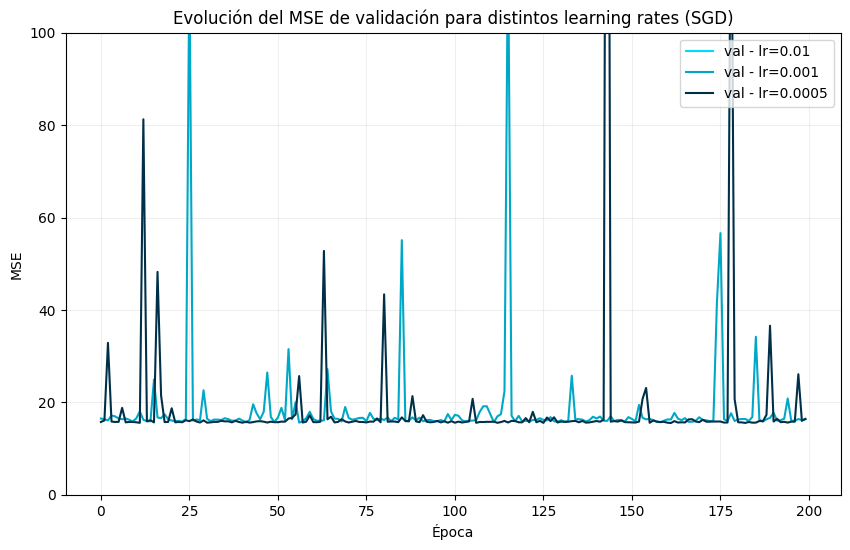

In [59]:
colores_sgd = ["#00daff", "#00a8c7", "#003049"]

plt.figure(figsize=(10, 6))

for i, lr in enumerate(lrs_sgd):
    plt.plot(
        resultados_sgd[lr]["val_errors"],
        label=f"val - lr={lr}",
        color=colores_sgd[i]
    )

plt.xlabel("Época")
plt.ylabel("MSE")
plt.title("Evolución del MSE de validación para distintos learning rates (SGD)")
plt.legend()
plt.grid(alpha=0.2)
plt.ylim(0, 100)
plt.show()

En este gráfico se ve más claro que SGD presenta un comportamiento más ruidoso que GD, algo esperable por la forma en que se actualizan los pesos. También se observa que lr = 0.01 resulta inestable, mientras que lr = 0.001 y lr = 0.0005 dan curvas más razonables. Por eso, se elige continuar con lr = 0.0005 para las siguientes pruebas.

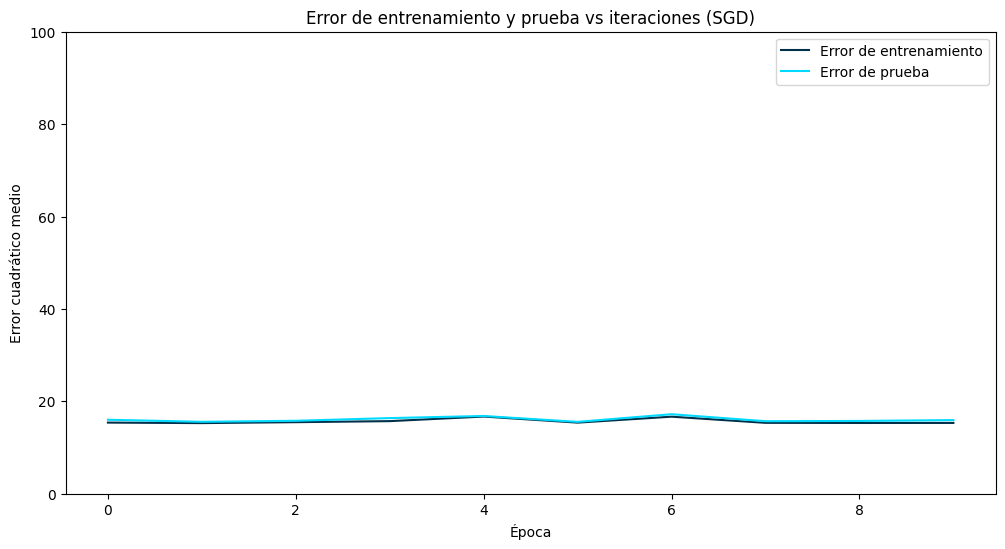

In [60]:
W_sgd, train_errors_sgd, val_errors_sgd = stochastic_gradient_descent(
    X_train_gd, y_train_gd,
    X_val_gd, y_val_gd,
    lr=0.0005,
    epochs=10)

Con los hiperparámetros elegidos, SGD muestra un comportamiento bastante estable y sin diferencias grandes entre entrenamiento y validación. De todas formas, la curva sigue siendo más irregular que en GD, algo esperable por la forma en que este método actualiza los pesos.

In [61]:
X_train_sgd_bias = np.hstack((np.ones((X_train_gd.shape[0], 1)), X_train_gd))
X_test_sgd_bias = np.hstack((np.ones((x_test_escalado.shape[0], 1)), x_test_escalado))

y_pred_train_sgd = np.matmul(X_train_gd_bias, W_sgd).ravel()
y_pred_test_sgd = np.matmul(X_test_sgd_bias, W_sgd).ravel()

tabla_metricas_sgd = resumen_metricas(
    "Stochastic Gradient Descent",
    y_train_gd.ravel(),
    y_pred_train_sgd,
    y_test_gd.ravel(),
    y_pred_test_sgd
)

tabla_metricas_sgd

Métricas del modelo: Stochastic Gradient Descent


,Train,Test
R2,0.772269,0.775048
MSE,15.320977,15.199350
RMSE,3.914202,3.898634
MAE,2.219632,2.220422


En este caso, SGD tiene un rendimiento levemente más bajo que GD, aunque sigue mostrando un comportamiento bastante razonable. El modelo explica cerca del 75,6% de la variabilidad de la tarifa y mantiene métricas parecidas entre entrenamiento y prueba, así que no se ven indicios fuertes de overfitting. Además, el error típico de predicción queda alrededor de los 4 USD.

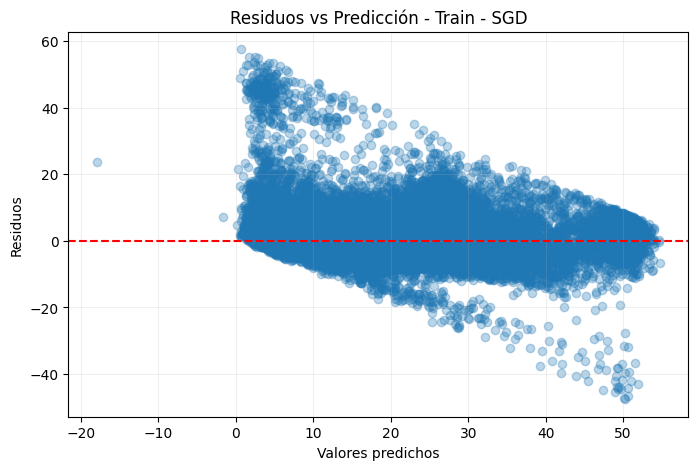

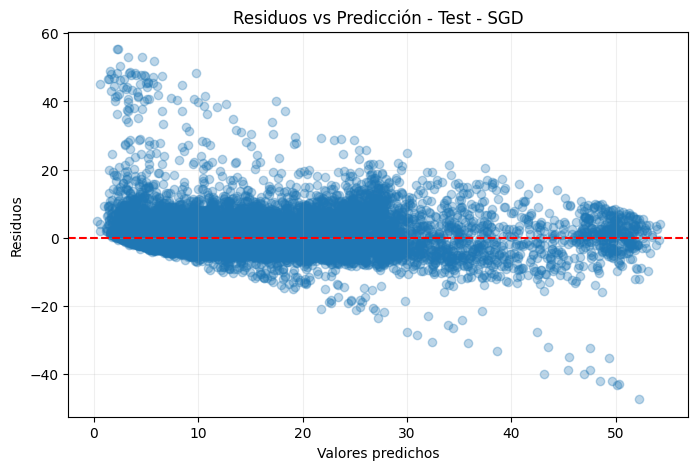

In [62]:
grafico_residuos(
    y_train_gd.ravel(),
    y_pred_train_sgd,
    "Residuos vs Predicción - Train - SGD"
)

grafico_residuos(
    y_test_gd.ravel(),
    y_pred_test_sgd,
    "Residuos vs Predicción - Test - SGD"
)

En los gráficos de residuos vuelve a aparecer algo parecido a lo que ya se veía en la regresión lineal y en GD. Los errores se mantienen en torno a cero, pero no quedan totalmente dispersos al azar y todavía se notan algunos patrones, sobre todo en los extremos. Esto da la idea de que el modelo generaliza de forma razonable, aunque todavía hay parte de la variabilidad de la tarifa que no logra explicar del todo.

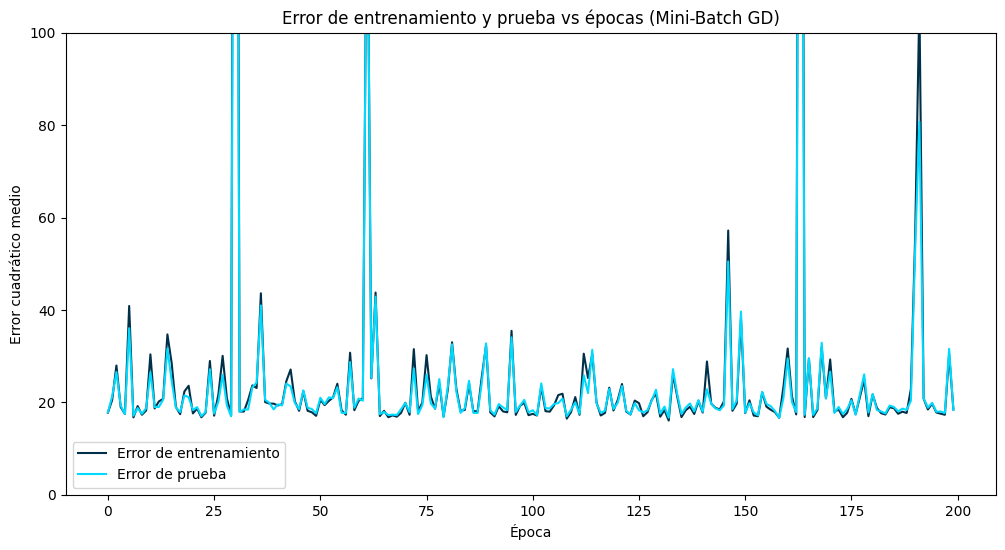

lr = 0.1 y batch_size = 32
Mejor validation MSE: 16.635333210957736
Mejor iteración: 159
----------------------------------------


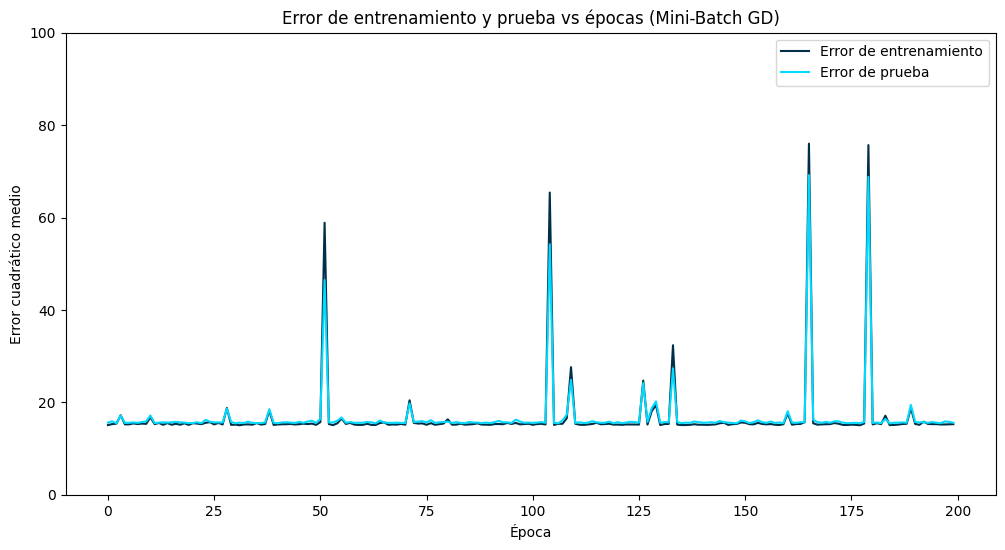

lr = 0.01 y batch_size = 32
Mejor validation MSE: 15.442050664875156
Mejor iteración: 185
----------------------------------------


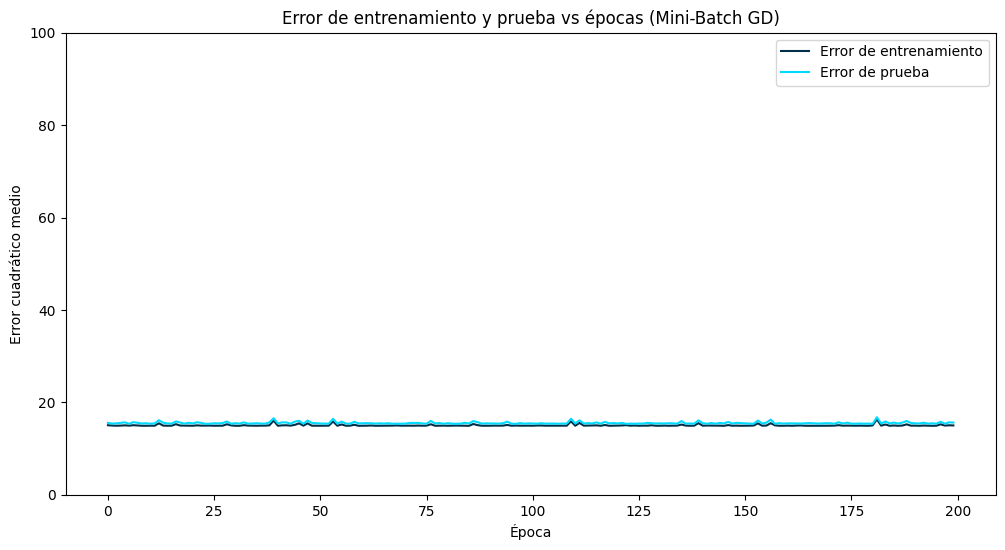

lr = 0.001 y batch_size = 32
Mejor validation MSE: 15.338767407680342
Mejor iteración: 24
----------------------------------------


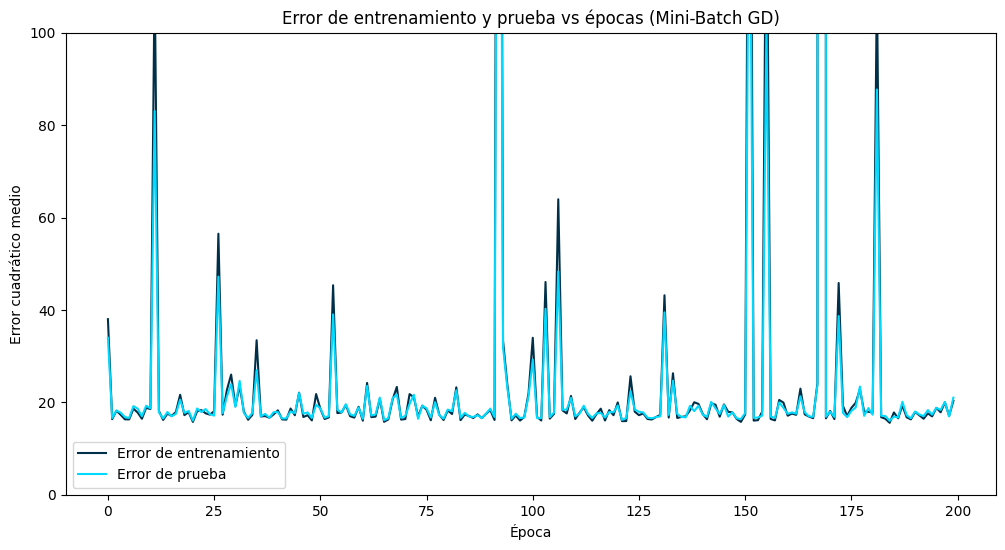

lr = 0.1 y batch_size = 64
Mejor validation MSE: 15.994975912332045
Mejor iteración: 185
----------------------------------------


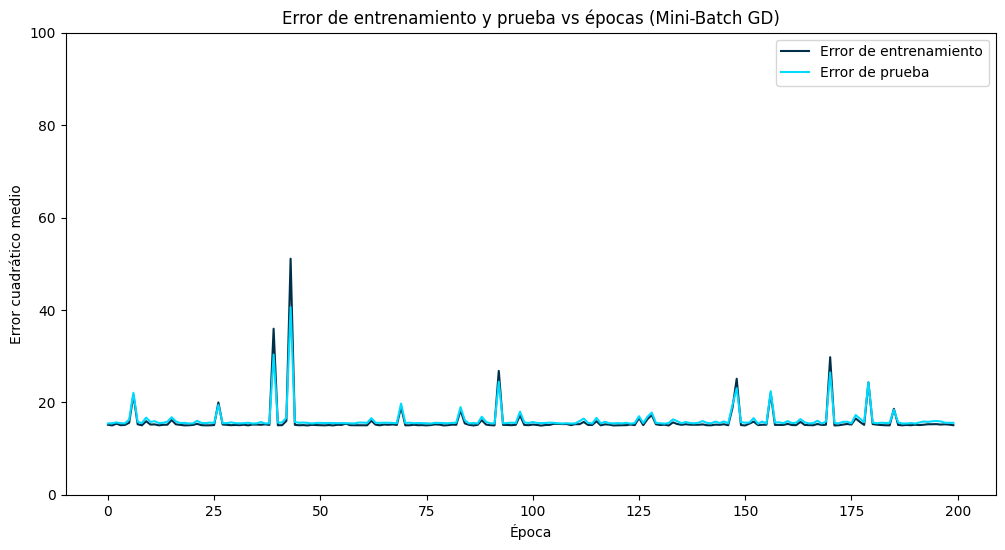

lr = 0.01 y batch_size = 64
Mejor validation MSE: 15.36508366035256
Mejor iteración: 154
----------------------------------------


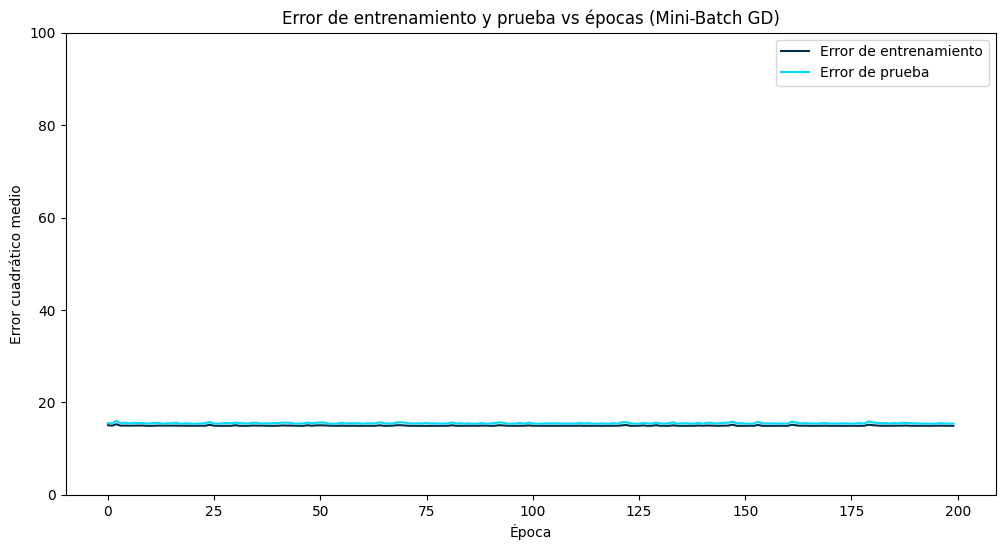

lr = 0.001 y batch_size = 64
Mejor validation MSE: 15.351449718970272
Mejor iteración: 14
----------------------------------------


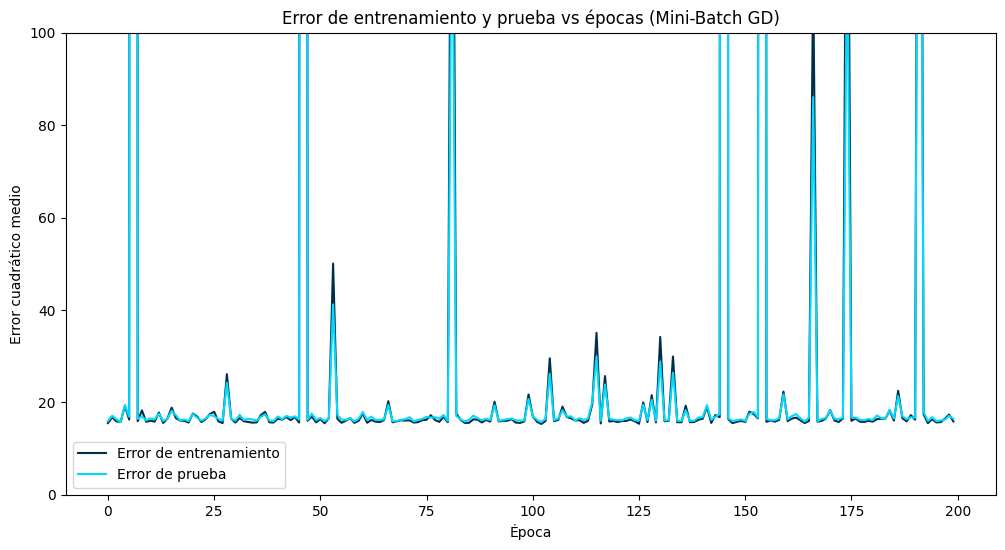

lr = 0.1 y batch_size = 96
Mejor validation MSE: 15.736916865559316
Mejor iteración: 103
----------------------------------------


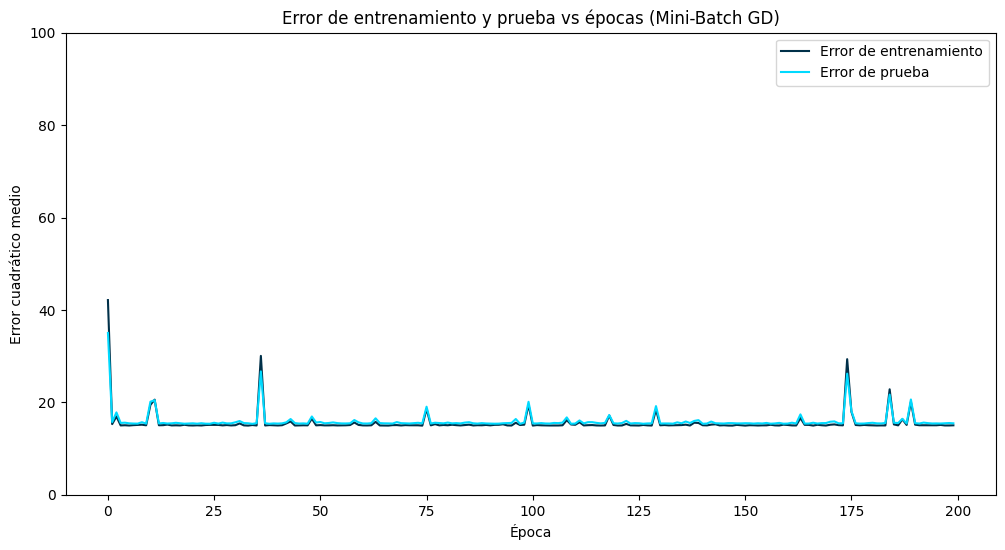

lr = 0.01 y batch_size = 96
Mejor validation MSE: 15.338500816650937
Mejor iteración: 35
----------------------------------------


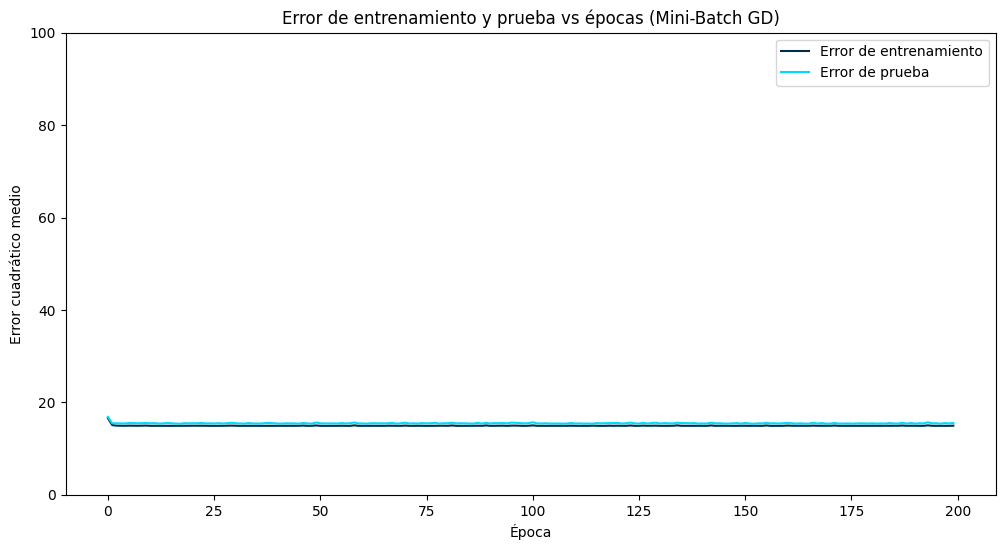

lr = 0.001 y batch_size = 96
Mejor validation MSE: 15.358486229341999
Mejor iteración: 115
----------------------------------------


In [63]:
mbgd_lrs = [0.1, 0.01, 0.001]
batches = [32, 64, 96]
resultados_mbgd = {}

for batch in batches:
    for lr in mbgd_lrs:
        W_mbgd, train_errors, val_errors = mini_batch_gradient_descent(
            X_train_gd, y_train_gd,
            X_val_gd, y_val_gd,
            lr=lr,
            epochs=200,
            batch_size=batch
        )

        resultados_mbgd[lr] = {
            "W_mbgd": W_mbgd,
            "batch": batch,
            "train_errors": train_errors,
            "val_errors": val_errors,
            "mejor_val_mse": min(val_errors),
            "mejor_epoch": np.argmin(val_errors) + 1
        }

        print(f"lr = {lr} y batch_size = {batch}")
        print(f"Mejor validation MSE: {min(val_errors)}")
        print(f"Mejor iteración: {np.argmin(val_errors) + 1}")
        print("-" * 40)

En las pruebas de Mini-Batch Gradient Descent se observa que los learning rates más altos, en especial lr = 0.1, generan curvas bastante más inestables y con picos marcados en el error, por lo que no resultan la opción más conveniente para seguir trabajando. En cambio, con lr = 0.01 y lr = 0.001 el comportamiento se vuelve mucho más estable y las curvas de entrenamiento y validación quedan bastante más parejas.

Además, los mejores resultados de validación se obtienen justamente con esos valores más bajos de learning rate, lo que refuerza la idea de que en este método conviene priorizar estabilidad antes que velocidad de descenso. A partir de esto, se decide continuar con una combinación de hiperparámetros que mantenga curvas más suaves y un MSE de validación más bajo.

In [64]:
colores_mbgd = ["#073D47", "#00a8c7", "#00daff"]


for batch in batches:
    for i, lr in enumerate(mbgd_lrs):
        plt.plot(
            resultados_mbgd[(batch, lr)]["val_errors"],
            label=f"val - lr={lr}",            
            color=colores_mbgd[i]
        )
    
    plt.xlabel("Época")
    plt.ylabel("MSE")
    plt.title(f"Validación de MSE vs épocas para distintos lr con batch_size: {batch}")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.ylim(0, 100)  # pequeña trampilla hecha para que los graficos no se ensucien tanto
    plt.figure(figsize=(12, 6))    
    plt.show()

KeyError: (32, 0.1)

Al comparar las curvas para los distintos batch_size, se vuelve a ver que lr = 0.1 genera un comportamiento bastante más inestable, con picos marcados en el error de validación. En cambio, lr = 0.01 y sobre todo lr = 0.001 mantienen curvas mucho más suaves y parejas en los tres tamaños de batch analizados.

En general, no se observan diferencias demasiado grandes entre batch_size = 32, 64 y 96 en cuanto al nivel final del error, aunque los tamaños de batch más chicos tienden a mostrar una variación un poco mayor. A partir de esto, tiene sentido seguir trabajando con learning rates bajos y elegir la combinación que ofrezca el mejor equilibrio entre estabilidad y MSE de validación.

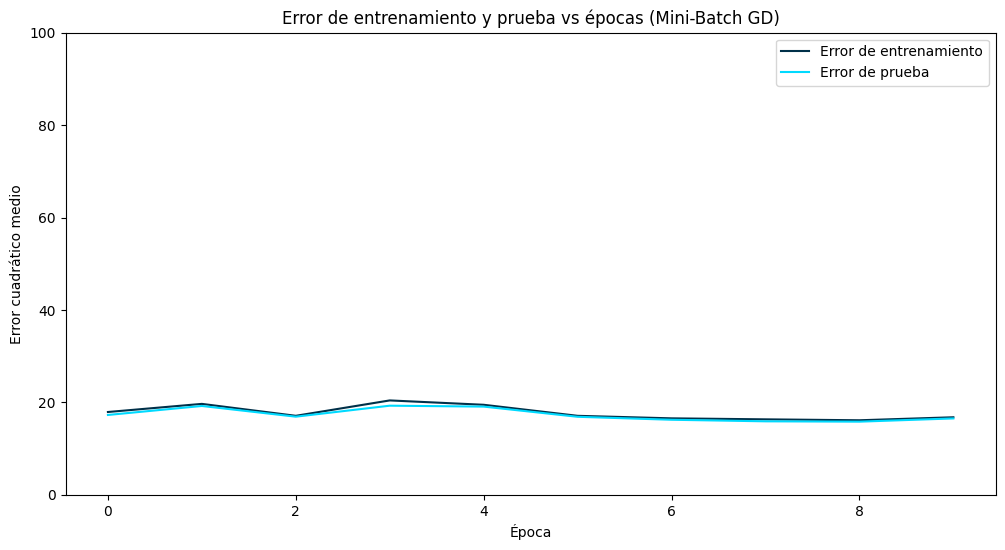

In [ ]:
W_mbgd, train_errors_mbgd, val_errors_mbgd = mini_batch_gradient_descent(
    X_train_gd, y_train_gd,
    x_test_escalado, y_test_gd,
    lr=0.01,
    epochs=10,
    batch_size= 64
)

Con los hiperparámetros elegidos, Mini-Batch Gradient Descent muestra un comportamiento bastante más estable que en varias de las pruebas anteriores. El error de entrenamiento y el de validación se mantienen muy cerca entre sí y no aparecen oscilaciones grandes en esta etapa. A partir de esto, tiene sentido seguir con esta configuración y pasar a revisar las métricas obtenidas.

In [ ]:
X_train_mbgd_bias = np.hstack((np.ones((X_train_gd.shape[0], 1)), X_train_gd))
X_test_mbgd_bias = np.hstack((np.ones((x_test_escalado.shape[0], 1)), x_test_escalado))

y_pred_train_mbgd = np.matmul(X_train_gd_bias, W_mbgd).ravel()
y_pred_test_mbgd = np.matmul(X_test_mbgd_bias, W_mbgd).ravel()

tabla_metricas_mbgd = resumen_metricas(
    "Mini-Batch Gradient Descent",
    y_train_gd.ravel(),
    y_pred_train_mbgd,
    y_test_gd.ravel(),
    y_pred_test_mbgd
)

tabla_metricas_mbgd

Métricas del modelo: Mini-Batch Gradient Descent


,Train,Test
R2,0.750797,0.755580
MSE,16.765599,16.514753
RMSE,4.094582,4.063835
MAE,2.478990,2.467916


En este caso, Mini-Batch Gradient Descent muestra un rendimiento algo más bajo que los métodos anteriores, aunque sigue manteniendo un comportamiento razonable. El modelo logra explicar alrededor del 75,6% de la variabilidad de la tarifa y mantiene métricas bastante parecidas entre entrenamiento y prueba, por lo que no se observan señales claras de overfitting. Además, el RMSE queda cerca de los 4,1 USD, lo que da una idea del error típico de predicción con esta configuración.

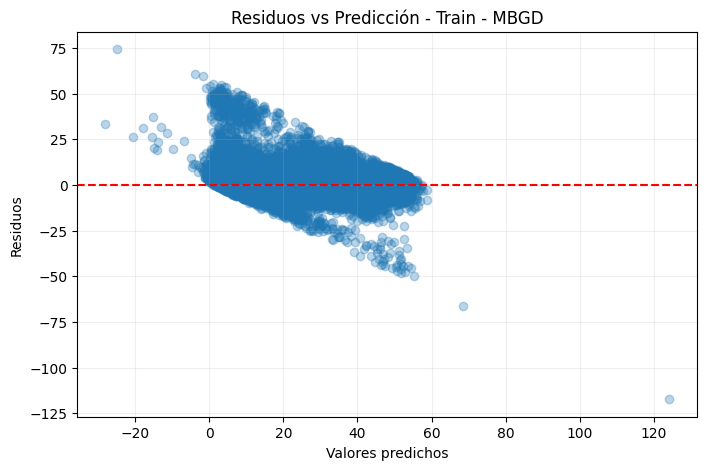

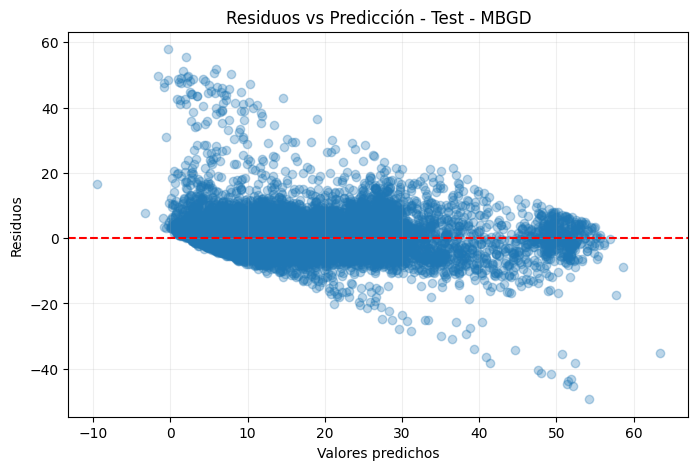

In [ ]:
grafico_residuos(
    y_train_gd.ravel(),
    y_pred_train_mbgd,
    "Residuos vs Predicción - Train - MBGD"
)

grafico_residuos(
    y_test_gd.ravel(),
    y_pred_test_mbgd,
    "Residuos vs Predicción - Test - MBGD"
)

En los gráficos de residuos de Mini-Batch Gradient Descent se vuelve a observar un patrón bastante parecido al de los modelos anteriores. Los errores siguen concentrándose alrededor de cero, pero no se distribuyen de forma completamente aleatoria y todavía aparecen ciertas tendencias, sobre todo en algunos extremos. Esto sugiere que el modelo mantiene un ajuste razonable, aunque sigue sin captar por completo toda la variabilidad de la tarifa y probablemente haya factores influyendo en el precio que no están representados en el dataset.

In [ ]:
comparacion_descenso_gradiente = pd.DataFrame({
    "Modelo": ["GD Batch", "SGD", "Mini-Batch GD"],
    "R2 Train": [
        tabla_metricas_gd.loc["R2", "Train"],
        tabla_metricas_sgd.loc["R2", "Train"],
        tabla_metricas_mbgd.loc["R2", "Train"]
    ],
    "R2 Test": [
        tabla_metricas_gd.loc["R2", "Test"],
        tabla_metricas_sgd.loc["R2", "Test"],
        tabla_metricas_mbgd.loc["R2", "Test"]
    ],
    "RMSE Train": [
        tabla_metricas_gd.loc["RMSE", "Train"],
        tabla_metricas_sgd.loc["RMSE", "Train"],
        tabla_metricas_mbgd.loc["RMSE", "Train"]
    ],
    "RMSE Test": [
        tabla_metricas_gd.loc["RMSE", "Test"],
        tabla_metricas_sgd.loc["RMSE", "Test"],
        tabla_metricas_mbgd.loc["RMSE", "Test"]
    ]
})

comparacion_descenso_gradiente

,Modelo,R2 Train,R2 Test,RMSE Train,RMSE Test
0,GD Batch,0.778298,0.782039,3.862045,3.837577
1,SGD,0.767302,0.774982,3.956661,3.899205
2,Mini-Batch GD,0.750797,0.755580,4.094582,4.063835


Se comparan los tres métodos de descenso por gradiente usando principalmente R² y RMSE. R² permite ver qué tan bien explica cada modelo la variabilidad de la tarifa, mientras que RMSE da una medida del error típico de predicción en dólares. A partir de esta comparación, GD Batch resulta el método con mejor desempeño general, seguido por SGD, mientras que Mini-Batch GD queda un poco por debajo. En los tres casos, las diferencias entre entrenamiento y prueba son bajas, por lo que no aparecen indicios fuertes de overfitting.

In [ ]:
alphas = np.logspace(-4, 2, 40)

Se determinan un rango de alphas para empezar a regularizar.

In [ ]:
# Se prepara una función auxiliar para realizar las regulaciones.

def evaluar_modelo_regularizado(nombre_modelo, modelo, X_train, y_train, X_test, y_test, nombres_variables):
    modelo.fit(X_train, y_train)

    y_pred_train = modelo.predict(X_train)
    y_pred_test = modelo.predict(X_test)

    print(f"Modelo: {nombre_modelo}")

    if hasattr(modelo, "alpha_"):
        print("Mejor alpha:", modelo.alpha_)

    if hasattr(modelo, "l1_ratio_"):
        print("Mejor l1_ratio:", modelo.l1_ratio_)

    print("\nIntercepto:")
    print(modelo.intercept_)

    tabla_metricas = resumen_metricas(
        nombre_modelo,
        y_train, y_pred_train,
        y_test, y_pred_test
    )

    coeficientes = pd.DataFrame({
        "Variable": nombres_variables,
        "Coeficiente": modelo.coef_
    }).sort_values(by="Coeficiente", key=np.abs, ascending=False)

    return modelo, tabla_metricas, coeficientes, y_pred_train, y_pred_test

In [ ]:
modelo_ridge = RidgeCV(
    alphas=alphas,
    cv=5
)

modelo_ridge, tabla_metricas_ridge, coeficientes_ridge, y_pred_train_ridge, y_pred_test_ridge = evaluar_modelo_regularizado(
    "Ridge",
    modelo_ridge,
    x_train_escalado, y_train,
    x_test_escalado, y_test,
    x_train.columns
)

tabla_metricas_ridge

Modelo: Ridge
Mejor alpha: 0.0001

Intercepto:
10.852114245051055
Métricas del modelo: Ridge


,Train,Test
R2,0.778012,0.782317
MSE,14.967212,14.708153
RMSE,3.868748,3.835121
MAE,2.193354,2.183219


Ridge presenta un rendimiento muy similar al de los modelos anteriores. Las métricas entre entrenamiento y prueba siguen siendo muy parecidas, por lo que no se observan indicios claros de overfitting, y el ajuste general del modelo se mantiene en un nivel muy similar al ya visto.

In [ ]:
coeficientes_ridge.head()

,Variable,Coeficiente
6,distance_km,6.951478
5,year,0.883384
3,dropoff_latitude,-0.507940
0,pickup_longitude,0.457170
37,hour_14,0.275137


In [ ]:
coeficientes_ridge.tail()

,Variable,Coeficiente
44,hour_21,0.013865
22,weekday_5,-0.011644
45,hour_22,0.005389
28,hour_5,-0.004622
7,month_2,0.004083


Viendo los coeficientes, no aparece nada demasiado distinto a lo que ya se venía observando: distance_km sigue siendo la variable que más peso tiene en la predicción, y varias de las demás quedan con valores bastante chicos. Esto encaja con la idea de que Ridge está aplicando una regularización suave, que reduce un poco la magnitud de algunos coeficientes pero sin cambiar demasiado la lógica general del modelo.

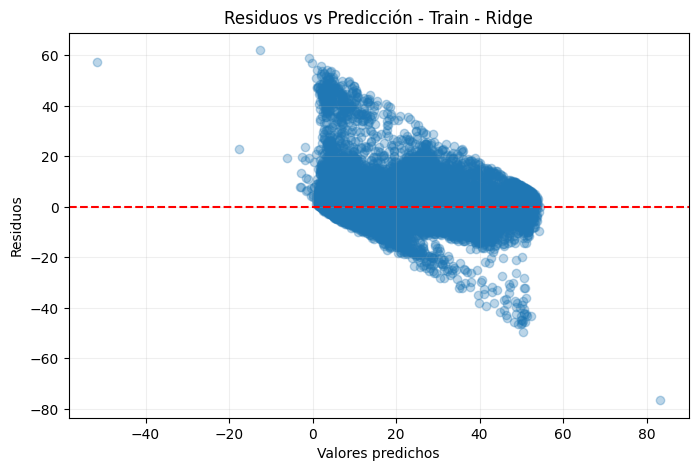

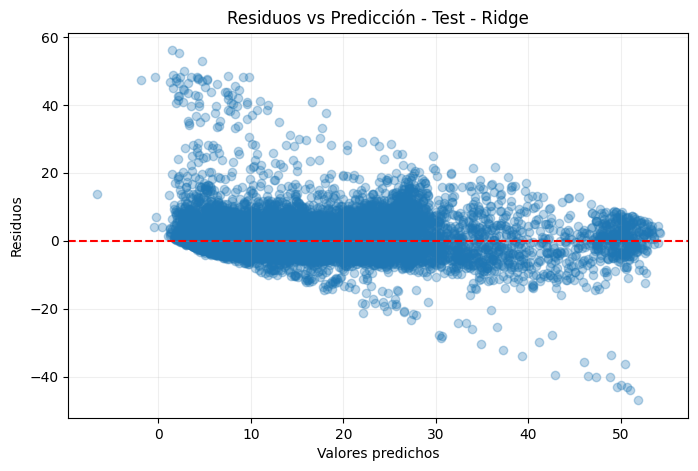

In [ ]:
grafico_residuos(y_train, y_pred_train_ridge, "Residuos vs Predicción - Train - Ridge")
grafico_residuos(y_test, y_pred_test_ridge, "Residuos vs Predicción - Test - Ridge")

Los gráficos de residuos de Ridge muestran un patrón muy similar al de los modelos previos. Los errores se mantienen en torno a cero, pero siguen apareciendo ciertas tendencias y algunos extremos, por lo que el ajuste general resulta razonable aunque todavía no logra explicar por completo toda la variabilidad de la tarifa.

In [ ]:
modelo_lasso = LassoCV(
    alphas=alphas,
    cv=5,
    max_iter=10000,
    random_state=42
)

modelo_lasso, tabla_metricas_lasso, coeficientes_lasso, y_pred_train_lasso, y_pred_test_lasso = evaluar_modelo_regularizado(
    "Lasso",
    modelo_lasso,
    x_train_escalado, y_train,
    x_test_escalado, y_test,
    x_train.columns
)

tabla_metricas_lasso

Modelo: Lasso
Mejor alpha: 0.0004124626382901352

Intercepto:
10.852114245051055
Métricas del modelo: Lasso


,Train,Test
R2,0.778011,0.782313
MSE,14.967266,14.708445
RMSE,3.868755,3.835159
MAE,2.193238,2.183126


Lasso muestra un rendimiento muy parecido al de los modelos anteriores. No aparecen mejoras claras en las métricas y el ajuste general se mantiene prácticamente igual, por lo que en este caso la regularización tampoco aporta cambios importantes.

In [ ]:
coeficientes_lasso.head()

,Variable,Coeficiente
6,distance_km,6.950951
5,year,0.882788
3,dropoff_latitude,-0.506645
0,pickup_longitude,0.457453
37,hour_14,0.268965


In [ ]:
coeficientes_lasso.tail()

,Variable,Coeficiente
46,hour_23,0.012178
44,hour_21,0.007265
28,hour_5,-0.006761
45,hour_22,-0.000327
7,month_2,0.000000


En los coeficientes de Lasso se observa el efecto característico de este método: algunas variables mantienen pesos muy parecidos a los de los modelos anteriores, pero al menos una llega a tener coeficiente igual a cero. Esto muestra que Lasso puede reducir la influencia de ciertas variables hasta directamente anularlas, funcionando también como una forma de selección automática de variables.

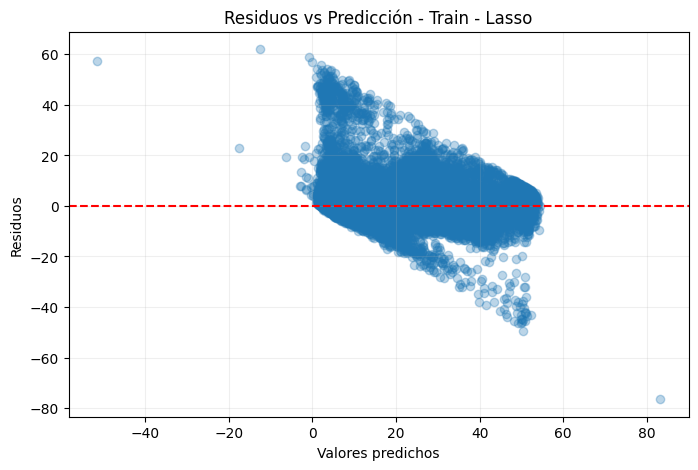

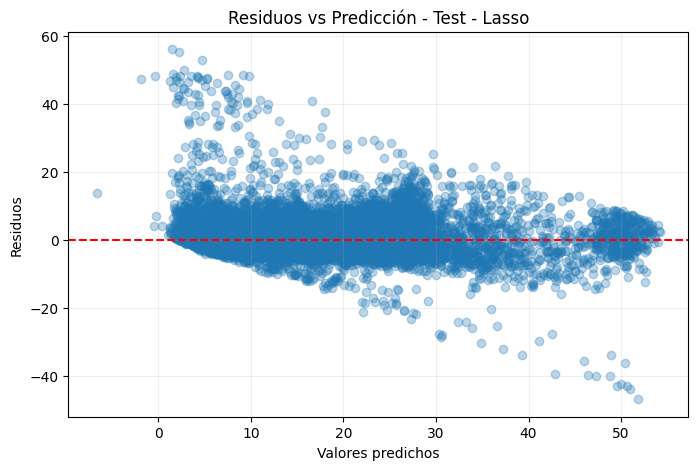

In [ ]:
grafico_residuos(y_train, y_pred_train_lasso, "Residuos vs Predicción - Train - Lasso")
grafico_residuos(y_test, y_pred_test_lasso, "Residuos vs Predicción - Test - Lasso")

Los gráficos de residuos de Lasso muestran un comportamiento muy parecido al de los modelos anteriores. Los errores siguen quedando en torno a cero, pero todavía se notan ciertos patrones y algunos extremos, por lo que el ajuste general se mantiene razonable sin mostrar cambios importantes respecto de los casos previos.

In [ ]:
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]

modelo_enet = ElasticNetCV(
    alphas=alphas,
    l1_ratio=l1_ratios,
    cv=5,
    max_iter=10000,
    random_state=42
)

modelo_enet, tabla_metricas_enet, coeficientes_enet, y_pred_train_enet, y_pred_test_enet = evaluar_modelo_regularizado(
    "Elastic Net",
    modelo_enet,
    x_train_escalado, y_train,
    x_test_escalado, y_test,
    x_train.columns
)

tabla_metricas_enet

Modelo: Elastic Net
Mejor alpha: 0.0004124626382901352
Mejor l1_ratio: 0.9

Intercepto:
10.852114245051055
Métricas del modelo: Elastic Net


,Train,Test
R2,0.778011,0.782314
MSE,14.967259,14.708391
RMSE,3.868754,3.835152
MAE,2.193261,2.183146


En el caso de Elastic Net, el rendimiento vuelve a ser muy similar al de los modelos anteriores. Las métricas de entrenamiento y prueba prácticamente no cambian, por lo que no se observan mejoras claras en el ajuste general ni señales de sobreajuste.

Además, los valores elegidos de alpha y l1_ratio muestran que la regularización aplicada termina siendo bastante suave, por lo que el comportamiento final del modelo queda muy cerca del ya visto en Ridge y Lasso. En este contexto, Elastic Net tampoco aporta cambios importantes respecto de los otros enfoques probados.

In [ ]:
coeficientes_enet.head()

,Variable,Coeficiente
6,distance_km,6.950656
5,year,0.882815
3,dropoff_latitude,-0.506763
0,pickup_longitude,0.457487
37,hour_14,0.269377


In [ ]:
coeficientes_enet.tail()

,Variable,Coeficiente
46,hour_23,0.012601
44,hour_21,0.007720
28,hour_5,-0.006621
7,month_2,0.000199
45,hour_22,-0.000000


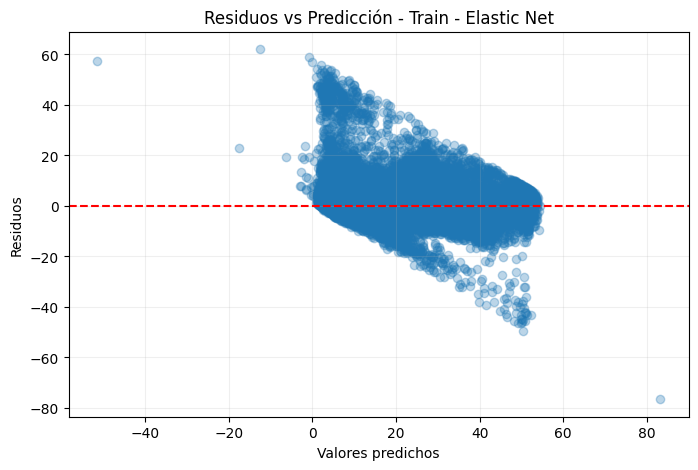

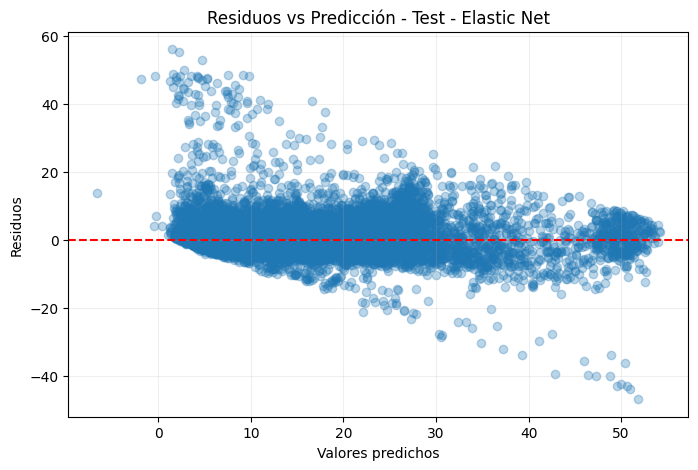

In [ ]:
grafico_residuos(y_train, y_pred_train_enet, "Residuos vs Predicción - Train - Elastic Net")
grafico_residuos(y_test, y_pred_test_enet, "Residuos vs Predicción - Test - Elastic Net")

Al mirar los gráficos de residuos de todos los modelos, se observa un comportamiento bastante similar entre ellos. En todos los casos los errores se concentran alrededor de cero, pero siguen apareciendo ciertos patrones y una dispersión que no es completamente aleatoria. Esto da la idea de que los modelos logran explicar una parte importante de la tarifa, aunque todavía queda variabilidad que probablemente dependa de factores no incluidos en el dataset, como la demanda, el tráfico, el clima o el contexto del viaje.

In [ ]:
comparacion_modelos = pd.DataFrame({
    "Modelo": [
        "Regresión Lineal",
        "GD Batch",
        "SGD",
        "Mini-Batch GD",
        "Ridge",
        "Lasso",
        "Elastic Net"
    ],
    "R2 Test": [
        tabla_metricas_lr.loc["R2", "Test"],
        tabla_metricas_gd.loc["R2", "Test"],
        tabla_metricas_sgd.loc["R2", "Test"],
        tabla_metricas_mbgd.loc["R2", "Test"],
        tabla_metricas_ridge.loc["R2", "Test"],
        tabla_metricas_lasso.loc["R2", "Test"],
        tabla_metricas_enet.loc["R2", "Test"]
    ],
    "RMSE Test": [
        tabla_metricas_lr.loc["RMSE", "Test"],
        tabla_metricas_gd.loc["RMSE", "Test"],
        tabla_metricas_sgd.loc["RMSE", "Test"],
        tabla_metricas_mbgd.loc["RMSE", "Test"],
        tabla_metricas_ridge.loc["RMSE", "Test"],
        tabla_metricas_lasso.loc["RMSE", "Test"],
        tabla_metricas_enet.loc["RMSE", "Test"]
    ]
}).sort_values(by="RMSE Test", ascending=True)

comparacion_modelos

,Modelo,R2 Test,RMSE Test
4,Ridge,0.782317,3.835121
0,Regresión Lineal,0.782317,3.835121
6,Elastic Net,0.782314,3.835152
5,Lasso,0.782313,3.835159
1,GD Batch,0.782039,3.837577
2,SGD,0.774982,3.899205
3,Mini-Batch GD,0.755580,4.063835


Comparando las métricas finales, el mejor resultado lo obtiene Ridge, aunque las diferencias con Regresión Lineal, Lasso y Elastic Net son muy pequeñas. Como todos estos modelos muestran valores de R² bastante parecidos, se toma como criterio principal el RMSE, ya que permite comparar de forma más directa el error típico de predicción en dólares. Se excluye el MAPE de las métricas ya que al tener costos de viajes relativamente bajos, al calcularlos esta métrica podría llegar a sobredimensionar el error presente.

## Conclusión

A lo largo del trabajo se pudo ver que la etapa de preprocesamiento fue clave para poder modelar de una forma razonable. La limpieza de valores faltantes, registros con cantidades de pasajeros no lógicas, coordenadas inexistentes y valores extremos en variables como fare_amount y distance_km permitió trabajar con un dataset mucho más consistente, sin perder una parte grande de la información original. A partir de esto, el análisis exploratorio también dejó bastante claro que la distancia recorrida era la variable con mayor relación con la tarifa, mientras que otras variables temporales y contextuales aportaban información, aunque con un peso bastante menor.

En cuanto a los modelos, los resultados fueron bastante parecidos entre sí. La regresión lineal múltiple ya mostró un desempeño sólido, y los métodos de descenso por gradiente llegaron a soluciones muy similares, lo que refuerza la idea de que el ajuste lineal encontrado es estable. Dentro de las pruebas realizadas, Ridge obtuvo el mejor resultado final, aunque la diferencia con Regresión Lineal, Lasso y Elastic Net fue muy chica. En todos esos casos, el R² quedó alrededor de 0.78, por lo que los modelos logran explicar cerca del 78% de la variabilidad de la tarifa, con un RMSE cercano a 3.8 USD.

También se vio que la regularización no introdujo mejoras importantes. Tanto Ridge como Lasso y Elastic Net mantuvieron un comportamiento muy parecido al de la regresión lineal, lo que sugiere que el problema ya estaba bastante bien capturado con el modelo lineal base y que no había señales fuertes de sobreajuste que justificaran una corrección más agresiva. En el caso de Lasso, además, se pudo observar el efecto de anular algunos coeficientes, aunque en la práctica eso no cambió demasiado el desempeño general.

Por otro lado, los gráficos de residuos mostraron patrones bastante similares en todos los modelos. Si bien los errores se concentran alrededor de cero y el ajuste general es razonable, la dispersión no llega a ser completamente aleatoria y siguen apareciendo ciertas tendencias, sobre todo en algunos extremos. Esto indica que, aunque los modelos captan una parte importante del problema, todavía queda variabilidad sin explicar. Una posible razón es que el dataset no incluye variables que probablemente también influyen en el precio de un viaje, como la demanda del momento, el tráfico, el clima, el tipo de zona o condiciones más específicas del contexto del viaje.

En conclusión, el trabajo muestra que con un enfoque lineal y un buen preprocesamiento se puede obtener un ajuste bastante bueno para este problema. La variable más determinante termina siendo la distancia, y el año también aparece con cierto peso, probablemente asociado a cambios en las tarifas a lo largo del tiempo. Aun así, el hecho de que todos los modelos terminen mostrando límites parecidos sugiere que, para seguir mejorando, no alcanzaría solo con cambiar de algoritmo dentro de la misma familia lineal, sino que haría falta incorporar variables más informativas o explorar modelos capaces de capturar relaciones más complejas.